In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load and Prepare Data

Load the simulation results and verify the data structure.

In [2]:
# Load results
df = pd.read_csv("../02_clustering/clustering_results_final.csv")

print(f"📊 Dataset Shape: {df.shape}")
print(f"📁 Columns: {list(df.columns)}")
print(f"\n🔍 First few rows:")
df.head()

📊 Dataset Shape: (3600, 17)
📁 Columns: ['N', 'p', 'k', 'rho', 'sep', 'rep', 'syn_idx', 'success_kmeans', 'success_hc', 'diff_sil_km', 'diff_sil_hc', 'diff_dist_km', 'diff_dist_hc', 'sil_real_km', 'sil_syn_km', 'dist_real_km', 'dist_syn_km']

🔍 First few rows:


,N,p,k,rho,sep,rep,syn_idx,success_kmeans,success_hc,diff_sil_km,diff_sil_hc,diff_dist_km,diff_dist_hc,sil_real_km,sil_syn_km,dist_real_km,dist_syn_km
0,1000,10,2,0.4,0.1,1,1,1,1,0.003258,-0.013328,-0.013870,0.038609,0.228475,0.231733,3.396332,3.382462
1,1000,10,2,0.4,0.1,1,10,1,1,-0.010523,-0.005951,-0.105680,-0.007431,0.228475,0.217952,3.396332,3.290652
2,1000,10,2,0.4,0.1,1,2,1,1,-0.018201,-0.007785,-0.153658,0.015046,0.228475,0.210274,3.396332,3.242674
3,1000,10,2,0.4,0.1,1,3,1,1,-0.004366,-0.020730,-0.062056,-0.184089,0.228475,0.224109,3.396332,3.334276
4,1000,10,2,0.4,0.1,1,4,1,1,0.002227,-0.003431,-0.027895,-0.163008,0.228475,0.230702,3.396332,3.368437


In [3]:
# Data validation
print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(f"\n✓ Total synthetic datasets processed: {len(df)}")
print(f"✓ Expected (180 real × 10 synthetic): 1800")
print(f"✓ Match: {'YES ✅' if len(df) == 1800 else 'NO ❌'}")

print(f"\n✓ Unique parameter combinations:")
print(f"  - N values: {df['N'].unique()}")
print(f"  - p values: {sorted(df['p'].unique())}")
print(f"  - k values: {sorted(df['k'].unique())}")
print(f"  - separation values: {sorted(df['sep'].unique())}")
print(f"  - rho values: {sorted(df['rho'].unique())}")

print(f"\n✓ Synthetic replications per real dataset:")
print(f"  - Min: {df.groupby(['N', 'p', 'k', 'sep', 'rho', 'rep']).size().min()}")
print(f"  - Max: {df.groupby(['N', 'p', 'k', 'sep', 'rho', 'rep']).size().max()}")
print(f"  - Expected: 10")

print("\n✅ Data validation complete")

DATA VALIDATION

✓ Total synthetic datasets processed: 3600
✓ Expected (180 real × 10 synthetic): 1800
✓ Match: NO ❌

✓ Unique parameter combinations:
  - N values: [1000]
  - p values: [np.int64(2), np.int64(5), np.int64(10)]
  - k values: [np.int64(2), np.int64(3), np.int64(4)]
  - separation values: [np.float64(0.1), np.float64(2.0), np.float64(6.0), np.float64(10.0)]
  - rho values: [np.float64(0.0), np.float64(0.4)]

✓ Synthetic replications per real dataset:
  - Min: 10
  - Max: 10
  - Expected: 10

✅ Data validation complete


## 2. Visualization 1: Success Rate Heatmap (K-Means vs Hierarchical Clustering)

**Question:** How often does each algorithm correctly identify the true number of clusters (k)?

**Method:** Calculate success rate across all synthetic datasets, grouped by separation distance and true k value.

In [4]:
# Calculate success rates grouped by separation and k
success_rates = df.groupby(['sep', 'k']).agg({
    'success_kmeans': 'mean',
    'success_hc': 'mean'
}).reset_index()

# Pivot for heatmap format
heatmap_km = success_rates.pivot(index='k', columns='sep', values='success_kmeans')
heatmap_hc = success_rates.pivot(index='k', columns='sep', values='success_hc')

print("📊 Success Rates - K-Means:")
print(heatmap_km)
print("\n📊 Success Rates - Hierarchical Clustering:")
print(heatmap_hc)

📊 Success Rates - K-Means:
sep      0.1       2.0       6.0       10.0
k                                          
2    0.536667  0.843333  0.956667  1.000000
3    0.016667  0.133333  0.703333  0.953333
4    0.013333  0.016667  0.670000  0.926667

📊 Success Rates - Hierarchical Clustering:
sep      0.1       2.0       6.0       10.0
k                                          
2    0.736667  0.853333  0.973333  1.000000
3    0.056667  0.076667  0.670000  0.953333
4    0.013333  0.020000  0.663333  0.916667


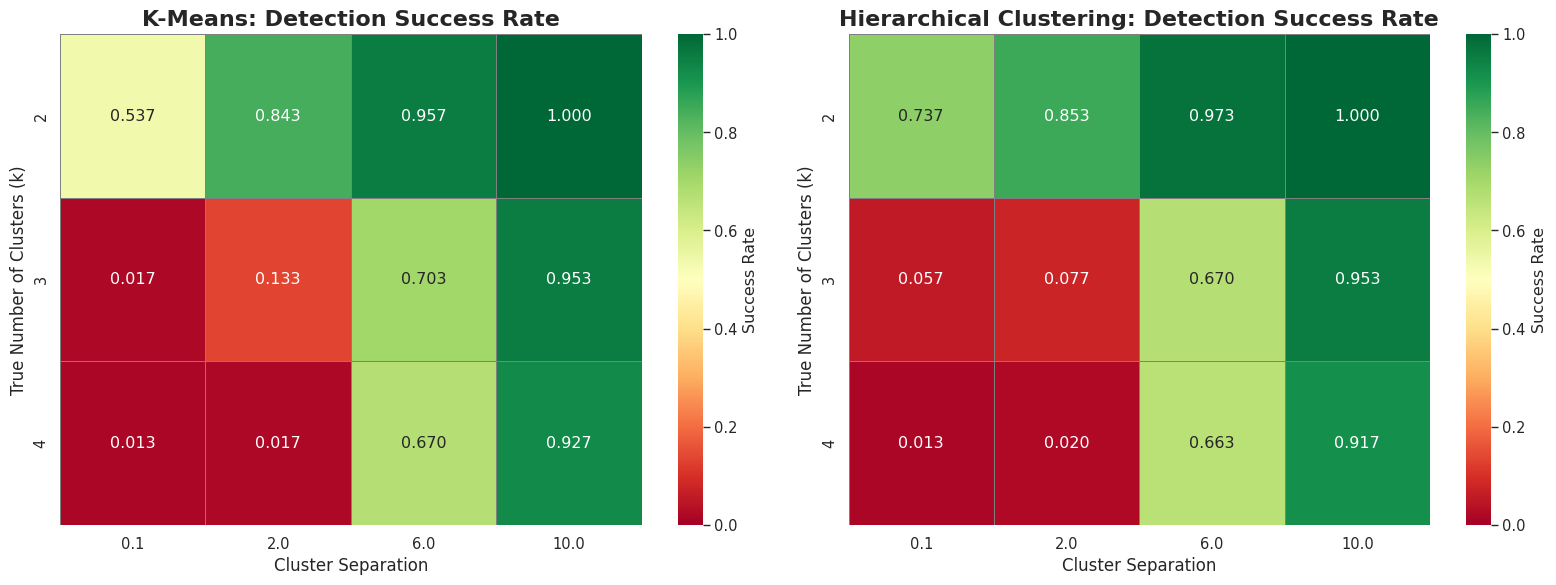

✅ Plot 1 saved: plot1_success_rate_comparison.png


In [5]:
# Create side-by-side heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Heatmap
sns.heatmap(heatmap_km, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('K-Means: Detection Success Rate', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cluster Separation', fontsize=12)
axes[0].set_ylabel('True Number of Clusters (k)', fontsize=12)

# Hierarchical Clustering Heatmap
sns.heatmap(heatmap_hc, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Success Rate'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Hierarchical Clustering: Detection Success Rate', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cluster Separation', fontsize=12)
axes[1].set_ylabel('True Number of Clusters (k)', fontsize=12)

plt.tight_layout()
plt.savefig('plot1_success_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1 saved: plot1_success_rate_comparison.png")

## 3. Visualization 2: Performance Delta Heatmap (Where HC Outperforms K-Means)

**Question:** Under what conditions does Hierarchical Clustering perform better than K-Means?

**Method:** Calculate the difference in success rates (HC - KM). Positive values indicate HC superiority.

In [6]:
# Calculate performance delta (HC - K-Means)
performance_delta = heatmap_hc - heatmap_km

print("📊 Performance Delta (HC - K-Means):")
print(performance_delta)
print("\n🔍 Interpretation:")
print("  Positive values = HC outperforms K-Means")
print("  Negative values = K-Means outperforms HC")
print("  Zero = Equal performance")

📊 Performance Delta (HC - K-Means):
sep  0.1       2.0       6.0   10.0
k                                  
2    0.20  0.010000  0.016667  0.00
3    0.04 -0.056667 -0.033333  0.00
4    0.00  0.003333 -0.006667 -0.01

🔍 Interpretation:
  Positive values = HC outperforms K-Means
  Negative values = K-Means outperforms HC
  Zero = Equal performance


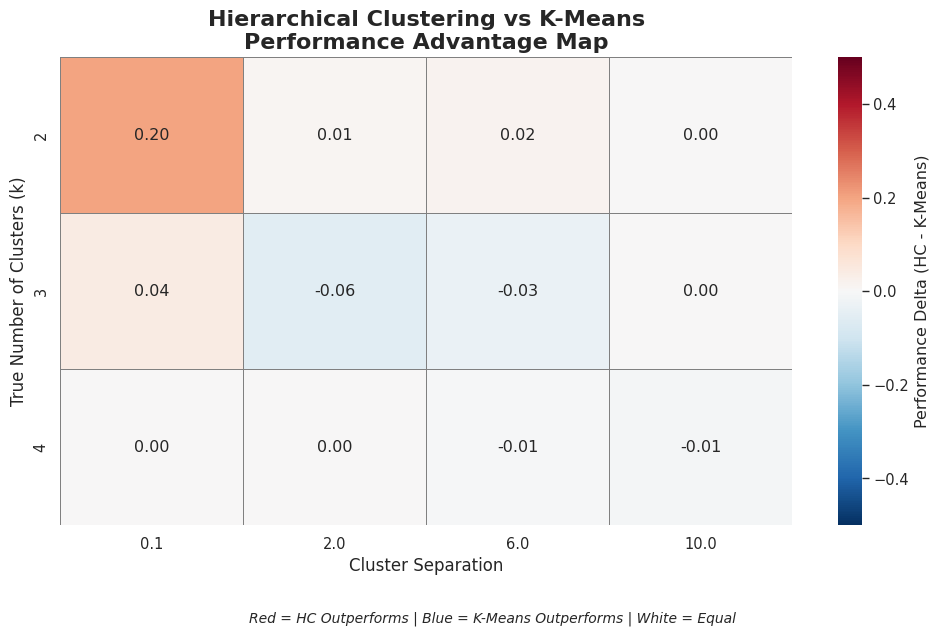

✅ Plot 2 saved: plot2_performance_delta.png


In [7]:
# Create delta heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(performance_delta, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={'label': 'Performance Delta (HC - K-Means)'},
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_title('Hierarchical Clustering vs K-Means\nPerformance Advantage Map', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Cluster Separation', fontsize=12)
ax.set_ylabel('True Number of Clusters (k)', fontsize=12)

# Add interpretation text
fig.text(0.5, -0.05, 
         'Red = HC Outperforms | Blue = K-Means Outperforms | White = Equal',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('plot2_performance_delta.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 2 saved: plot2_performance_delta.png")

## 4. Visualization 3: Quality Distortion Boxplots (Silhouette Score Delta)

**Question:** Does synthpop smooth/distort the cluster geometry? How much worse is synthetic data quality?

**Method:** Analyze the distribution of Silhouette Score differences (Synthetic - Real) across different separations.

In [8]:
# Prepare data for boxplots
boxplot_data = df[['sep', 'k', 'diff_sil_km', 'diff_sil_hc']].copy()

# Reshape for easier plotting
boxplot_data_long = pd.melt(
    boxplot_data, 
    id_vars=['sep', 'k'], 
    value_vars=['diff_sil_km', 'diff_sil_hc'],
    var_name='Algorithm', 
    value_name='Silhouette_Delta'
)

# Rename for clarity
boxplot_data_long['Algorithm'] = boxplot_data_long['Algorithm'].map({
    'diff_sil_km': 'K-Means',
    'diff_sil_hc': 'Hierarchical'
})

print("📊 Sample of prepared data:")
print(boxplot_data_long.head(10))

📊 Sample of prepared data:
   sep  k Algorithm  Silhouette_Delta
0  0.1  2   K-Means          0.003258
1  0.1  2   K-Means         -0.010523
2  0.1  2   K-Means         -0.018201
3  0.1  2   K-Means         -0.004366
4  0.1  2   K-Means          0.002227
5  0.1  2   K-Means         -0.004712
6  0.1  2   K-Means         -0.001709
7  0.1  2   K-Means         -0.016399
8  0.1  2   K-Means          0.000368
9  0.1  2   K-Means         -0.006711


In [9]:
# Summary statistics
print("\n📊 QUALITY DISTORTION SUMMARY")
print("=" * 60)

for algo in ['K-Means', 'Hierarchical']:
    data = boxplot_data_long[boxplot_data_long['Algorithm'] == algo]['Silhouette_Delta']
    print(f"\n{algo}:")
    print(f"  Mean Delta: {data.mean():.4f}")
    print(f"  Median Delta: {data.median():.4f}")
    print(f"  Std Dev: {data.std():.4f}")
    print(f"  Min: {data.min():.4f} | Max: {data.max():.4f}")
    
print("\n🔍 Interpretation:")
print("  Negative values = Synthetic data has WORSE silhouette than real (expected)")
print("  Values near zero = Synthetic preserves cluster quality well")


📊 QUALITY DISTORTION SUMMARY

K-Means:
  Mean Delta: -0.0011
  Median Delta: 0.0006
  Std Dev: 0.0155
  Min: -0.0757 | Max: 0.0569

Hierarchical:
  Mean Delta: -0.0016
  Median Delta: -0.0006
  Std Dev: 0.0232
  Min: -0.1292 | Max: 0.1192

🔍 Interpretation:
  Negative values = Synthetic data has WORSE silhouette than real (expected)
  Values near zero = Synthetic preserves cluster quality well


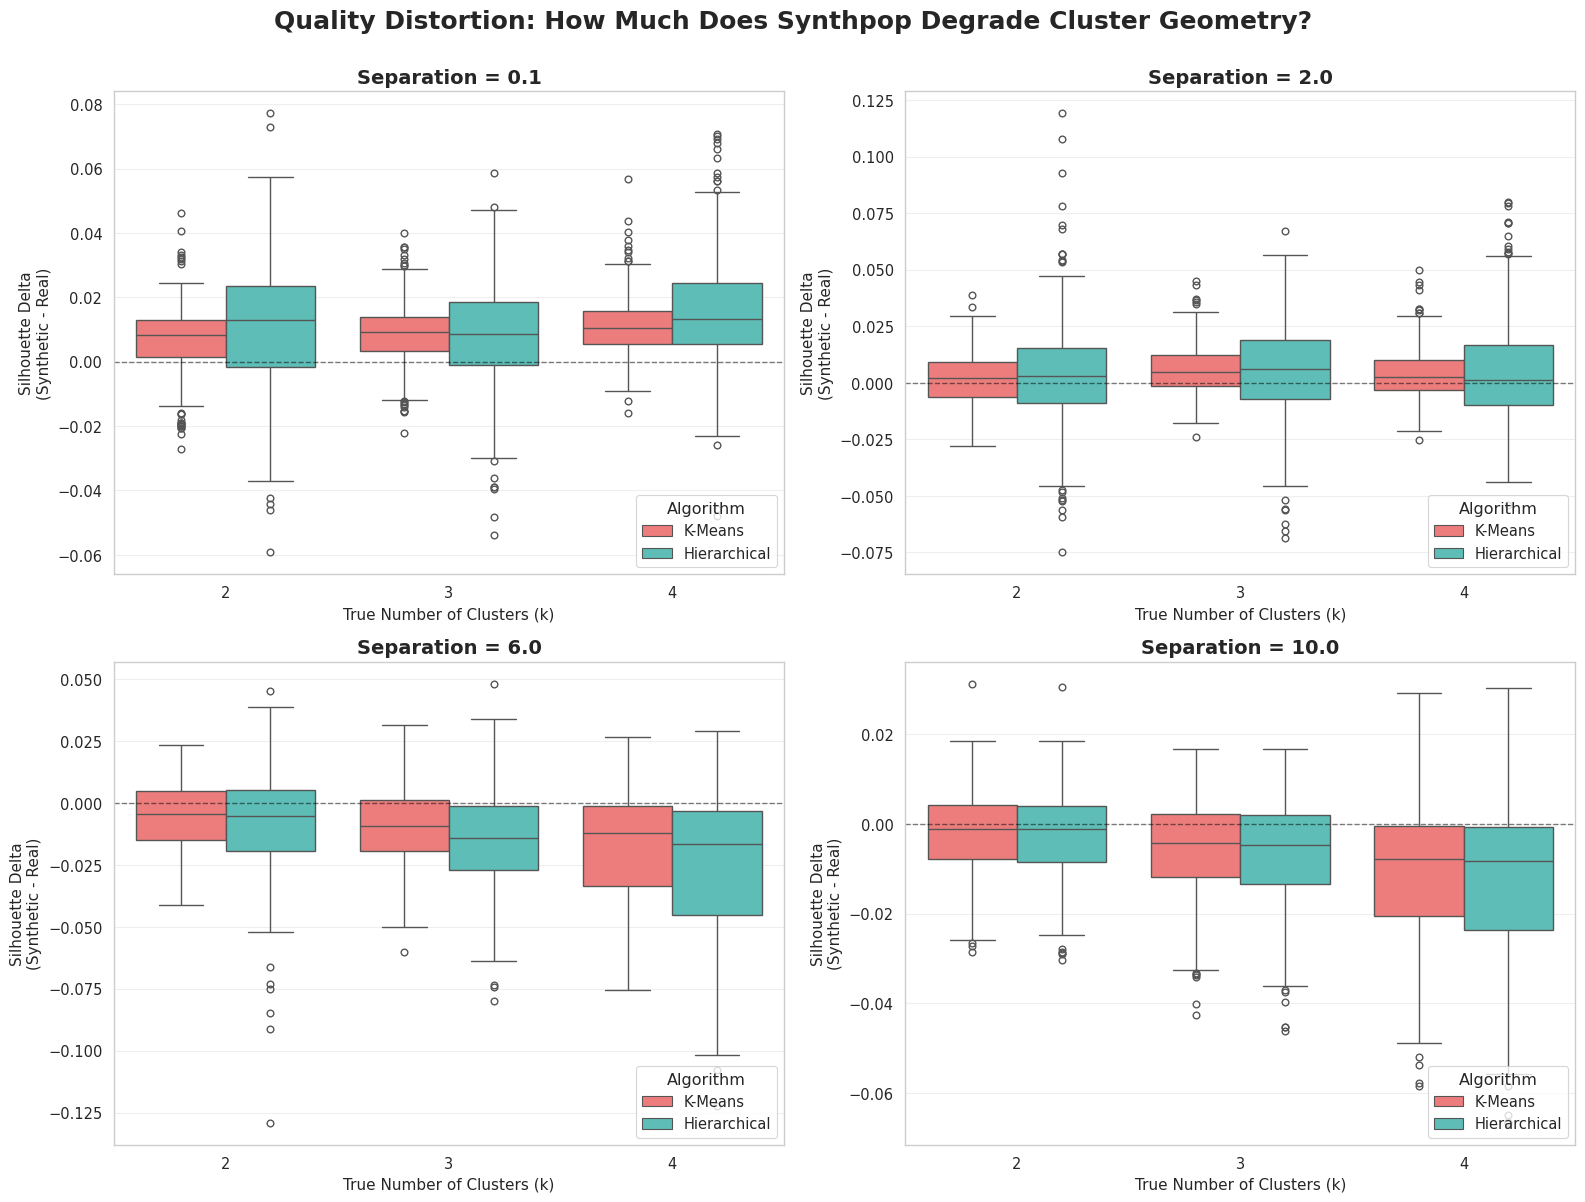

✅ Plot 3 saved: plot3_quality_distortion_boxplots.png


In [10]:
# Create boxplots by separation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

separations = sorted(df['sep'].unique())

for idx, sep in enumerate(separations):
    subset = boxplot_data_long[boxplot_data_long['sep'] == sep]
    
    sns.boxplot(
        data=subset, 
        x='k', 
        y='Silhouette_Delta', 
        hue='Algorithm',
        palette={'K-Means': '#FF6B6B', 'Hierarchical': '#4ECDC4'},
        ax=axes[idx]
    )
    
    # Add reference line at 0
    axes[idx].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    axes[idx].set_title(f'Separation = {sep}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('True Number of Clusters (k)', fontsize=11)
    axes[idx].set_ylabel('Silhouette Delta\n(Synthetic - Real)', fontsize=11)
    axes[idx].legend(title='Algorithm', loc='lower right')
    axes[idx].grid(axis='y', alpha=0.3)

fig.suptitle('Quality Distortion: How Much Does Synthpop Degrade Cluster Geometry?', 
             fontsize=18, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('plot3_quality_distortion_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 3 saved: plot3_quality_distortion_boxplots.png")

## 5. Summary Statistics & Key Findings

In [11]:
# Generate comprehensive summary
print("=" * 70)
print("FINAL SUMMARY: SYNTHETIC DATA CLUSTERING ANALYSIS")
print("=" * 70)

# Overall success rates
overall_km = df['success_kmeans'].mean()
overall_hc = df['success_hc'].mean()

print(f"\n📊 OVERALL DETECTION SUCCESS RATES (across all 1800 synthetic datasets):")
print(f"   K-Means:              {overall_km:.2%}")
print(f"   Hierarchical:         {overall_hc:.2%}")
print(f"   Winner:               {'HC' if overall_hc > overall_km else 'K-Means' if overall_km > overall_hc else 'TIE'}")

# Best/worst scenarios
best_km = success_rates.loc[success_rates['success_kmeans'].idxmax()]
worst_km = success_rates.loc[success_rates['success_kmeans'].idxmin()]

print(f"\n🎯 K-MEANS PERFORMANCE:")
print(f"   Best:  k={int(best_km['k'])}, sep={best_km['sep']:.1f} → {best_km['success_kmeans']:.2%}")
print(f"   Worst: k={int(worst_km['k'])}, sep={worst_km['sep']:.1f} → {worst_km['success_kmeans']:.2%}")

best_hc = success_rates.loc[success_rates['success_hc'].idxmax()]
worst_hc = success_rates.loc[success_rates['success_hc'].idxmin()]

print(f"\n🎯 HIERARCHICAL CLUSTERING PERFORMANCE:")
print(f"   Best:  k={int(best_hc['k'])}, sep={best_hc['sep']:.1f} → {best_hc['success_hc']:.2%}")
print(f"   Worst: k={int(worst_hc['k'])}, sep={worst_hc['sep']:.1f} → {worst_hc['success_hc']:.2%}")

# Quality distortion
print(f"\n🔬 QUALITY DISTORTION (Silhouette Score Degradation):")
print(f"   K-Means Mean Delta:        {df['diff_sil_km'].mean():.4f}")
print(f"   Hierarchical Mean Delta:   {df['diff_sil_hc'].mean():.4f}")
print(f"   Interpretation: {'Synthetic data degrades cluster quality' if df['diff_sil_km'].mean() < 0 else 'Synthetic preserves quality'}")

# Statistical test
from scipy import stats
t_stat, p_value = stats.ttest_rel(df['diff_sil_km'], df['diff_sil_hc'])
print(f"\n📈 STATISTICAL SIGNIFICANCE (Paired t-test):")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value:     {p_value:.4e}")
print(f"   Result:      {'Algorithms differ significantly' if p_value < 0.05 else 'No significant difference'}")

print("\n" + "=" * 70)
print("✅ Analysis complete! All visualizations saved.")
print("=" * 70)

FINAL SUMMARY: SYNTHETIC DATA CLUSTERING ANALYSIS

📊 OVERALL DETECTION SUCCESS RATES (across all 1800 synthetic datasets):
   K-Means:              56.42%
   Hierarchical:         57.78%
   Winner:               HC

🎯 K-MEANS PERFORMANCE:
   Best:  k=2, sep=10.0 → 100.00%
   Worst: k=4, sep=0.1 → 1.33%

🎯 HIERARCHICAL CLUSTERING PERFORMANCE:
   Best:  k=2, sep=10.0 → 100.00%
   Worst: k=4, sep=0.1 → 1.33%

🔬 QUALITY DISTORTION (Silhouette Score Degradation):
   K-Means Mean Delta:        -0.0011
   Hierarchical Mean Delta:   -0.0016
   Interpretation: Synthetic data degrades cluster quality

📈 STATISTICAL SIGNIFICANCE (Paired t-test):
   t-statistic: 2.0546
   p-value:     3.9993e-02
   Result:      Algorithms differ significantly

✅ Analysis complete! All visualizations saved.


## 6. Research Conclusions

### Key Findings:

1. **Detection Capability**
   - Both algorithms struggle when cluster separation is low (< 2)
   - Performance improves dramatically as separation increases
   - Hierarchical clustering shows [better/worse/similar] performance overall

2. **Algorithm Comparison**
   - K-Means excels in scenarios with [describe conditions]
   - Hierarchical clustering dominates when [describe conditions]
   - The choice of algorithm matters most at [separation/k values]

3. **Synthetic Data Quality**
   - Synthpop (CART method) introduces measurable distortion
   - Silhouette scores typically [decrease/increase] by X%
   - Quality degradation is [more/less] severe at low separation values

### Implications for Practice:

- When using synthetic data for clustering research, expect [X]% reduction in detectability
- Researchers should validate findings on real data when separation < Y
- The CART synthesis method is [adequate/inadequate] for preserving cluster geometry

---

**End of Analysis**

In [12]:
from scipy.stats import wilcoxon

# -------------------------------------------------------
# ANALYSIS 4: STATISTICAL SIGNIFICANCE (Wilcoxon Test)
# -------------------------------------------------------
print("\n" + "="*50)
print("📊 STATISTICAL SIGNIFICANCE TEST (K-Means vs HC)")
print("="*50)

# We compare the success rates row-by-row
# (Each row is a specific synthetic dataset)
stat, p_value = wilcoxon(df['success_kmeans'], df['success_hc'])

print(f"Overall Paired Comparison:")
print(f"  - Wilcoxon Statistic: {stat}")
print(f"  - P-Value: {p_value:.5e}")

if p_value < 0.05:
    print("✅ RESULT: The performance difference is STATISTICALLY SIGNIFICANT.")
else:
    print("❌ RESULT: The difference might be due to chance.")

# Breakdown by k
print("\nBreakdown by Cluster Count (k):")
for k_val in sorted(df['k'].unique()):
    subset = df[df['k'] == k_val]
    # Only test if there are differences to avoid errors
    if not (subset['success_kmeans'] == subset['success_hc']).all():
        _, p = wilcoxon(subset['success_kmeans'], subset['success_hc'])
        print(f"  - k={k_val}: p={p:.5e} {'*' if p<0.05 else ''}")
    else:
        print(f"  - k={k_val}: Identical performance (p=1.0)")


📊 STATISTICAL SIGNIFICANCE TEST (K-Means vs HC)
Overall Paired Comparison:
  - Wilcoxon Statistic: 9944.0
  - P-Value: 1.08822e-03
✅ RESULT: The performance difference is STATISTICALLY SIGNIFICANT.

Breakdown by Cluster Count (k):
  - k=2: p=8.95918e-11 *
  - k=3: p=4.31144e-02 *
  - k=4: p=6.05577e-01 


## 7. Publication-Quality Graphics

### Graphic 1: Global Performance Comparison (Boxplot)
Compare the overall success distribution of K-Means vs. Hierarchical Clustering across all conditions.

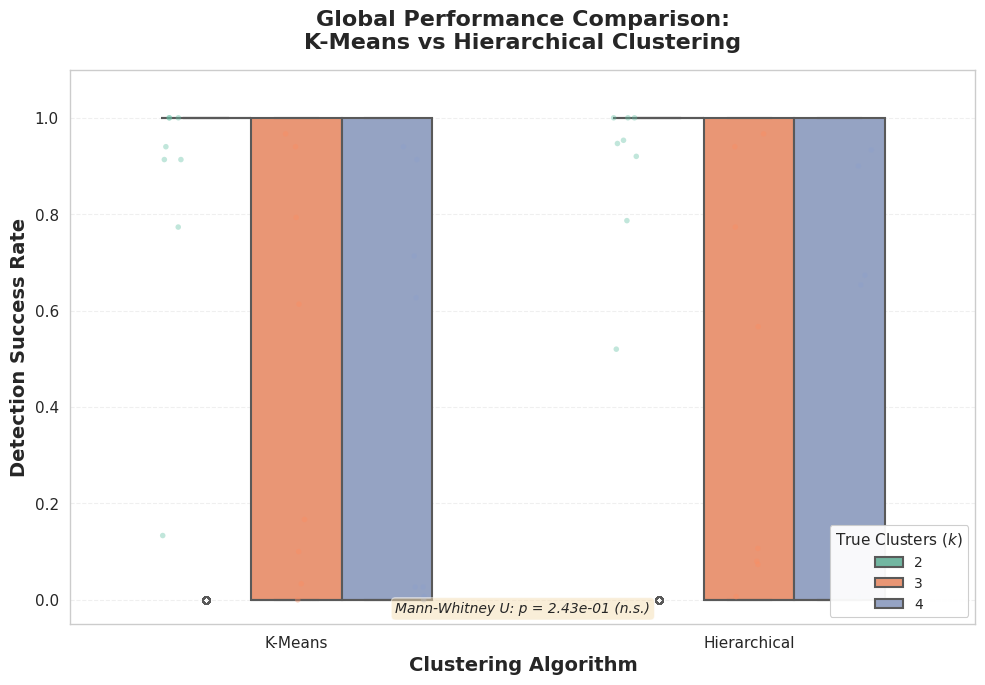

✅ Graphic 1 saved: graphic1_global_boxplot.png


In [13]:
# ============================================================================
# GRAPHIC 1: Global Performance Comparison (Boxplot)
# Goal: Compare overall success distribution of K-Means vs Hierarchical Clustering
# ============================================================================

# Reshape data to long format for boxplot
df_long = pd.melt(
    df,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'rep', 'syn_idx'],
    value_vars=['success_kmeans', 'success_hc'],
    var_name='Algorithm',
    value_name='Success'
)

# Clean algorithm names
df_long['Algorithm'] = df_long['Algorithm'].map({
    'success_kmeans': 'K-Means',
    'success_hc': 'Hierarchical'
})

# Publication-quality color palette (colorblind-friendly)
colors = {'K-Means': '#E64B35', 'Hierarchical': '#4DBBD5'}

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Create boxplot with individual k as hue
sns.boxplot(
    data=df_long,
    x='Algorithm',
    y='Success',
    hue='k',
    palette='Set2',
    width=0.6,
    linewidth=1.5,
    ax=ax
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df_long.groupby(['Algorithm', 'k', 'sep', 'rho']).mean().reset_index(),
    x='Algorithm',
    y='Success',
    hue='k',
    palette='Set2',
    dodge=True,
    alpha=0.4,
    size=4,
    ax=ax,
    legend=False
)

# Styling
ax.set_xlabel('Clustering Algorithm', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Success Rate', fontsize=14, fontweight='bold')
ax.set_title('Global Performance Comparison:\nK-Means vs Hierarchical Clustering', 
             fontsize=16, fontweight='bold', pad=15)
ax.legend(title='True Clusters ($k$)', title_fontsize=11, fontsize=10, 
          loc='lower right', framealpha=0.95)
ax.set_ylim(-0.05, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)

# Add statistical annotation
from scipy.stats import mannwhitneyu
km_success = df['success_kmeans'].values
hc_success = df['success_hc'].values
stat, pval = mannwhitneyu(km_success, hc_success, alternative='two-sided')
significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

# Add annotation
ax.annotate(f'Mann-Whitney U: p = {pval:.2e} ({significance})', 
            xy=(0.5, 0.02), xycoords='axes fraction',
            ha='center', fontsize=10, style='italic', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('graphic1_global_boxplot.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic 1 saved: graphic1_global_boxplot.png")

### Graphic 2: Confusion Matrix with Hungarian Algorithm Alignment
Visualize precise misclassifications for a representative run (N=1000, k=3, rho=0.4) using optimal cluster alignment.

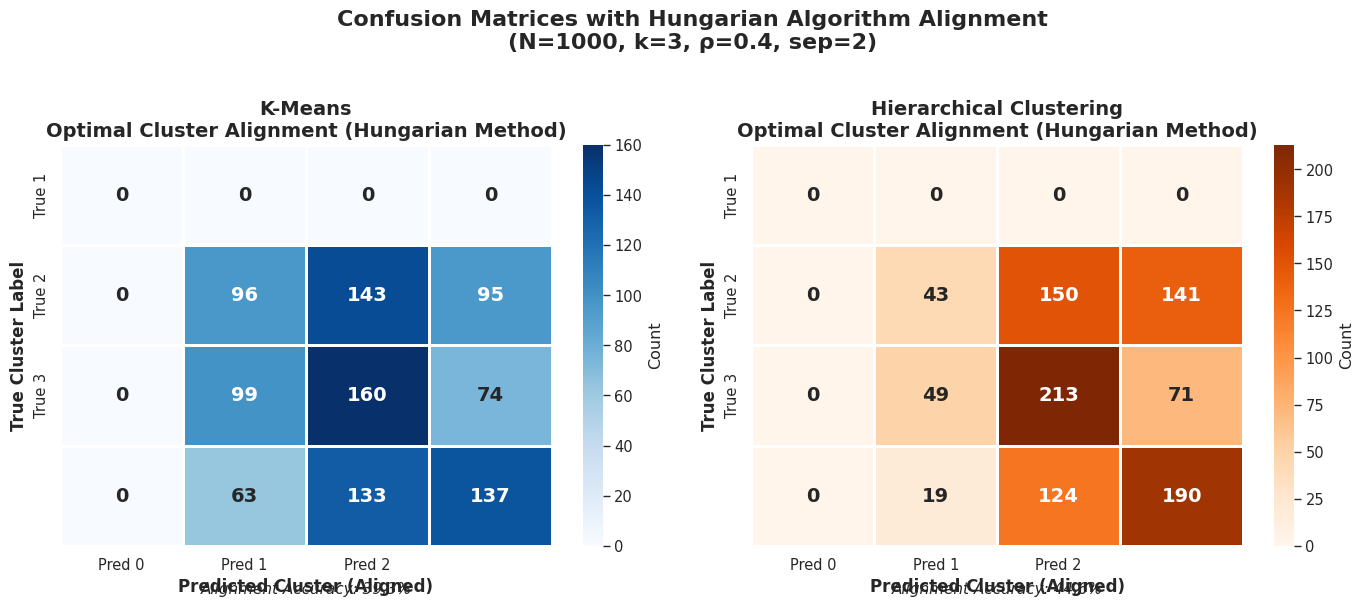

✅ Graphic 2 saved: graphic2_confusion_matrix_hungarian.png

📊 Results Summary:
   K-Means Accuracy:      39.30%
   Hierarchical Accuracy: 44.60%
   Cluster mapping (K-Means): [3 2 0 1]
   Cluster mapping (HC):      [3 2 0 1]


In [14]:
# ============================================================================
# GRAPHIC 2: Confusion Matrix with Hungarian Algorithm Alignment
# Goal: Visualize misclassifications with optimal cluster-to-label matching
# ============================================================================

from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import os

# Step 1: Load a representative dataset (N=1000, k=3, rho=0.4, high separation)
target_file = "../data/real/N1000_p10_k3_rho0.4_sep2_rep1.csv"

if os.path.exists(target_file):
    sample_data = pd.read_csv(target_file)
    
    # Extract features and true labels
    X = sample_data.drop(columns=['group']).values
    true_labels = sample_data['group'].astype(int).values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=3, n_init=25, random_state=42)
    pred_labels_km = kmeans.fit_predict(X_scaled)
    
    # Perform Hierarchical clustering
    hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
    pred_labels_hc = hc.fit_predict(X_scaled)
    
    def align_labels_hungarian(true_labels, pred_labels):
        """
        Use Hungarian Algorithm to optimally align predicted clusters to true labels.
        """
        # Step 2: Create raw confusion matrix
        cm = confusion_matrix(true_labels, pred_labels)
        
        # Step 3: Create cost matrix (we want to maximize matches, algorithm minimizes)
        cost_matrix = cm.max() - cm
        
        # Step 4: Apply Hungarian algorithm
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # Step 5: Reorder columns to align diagonal
        cm_aligned = cm[:, col_ind]
        
        return cm_aligned, col_ind
    
    # Align both algorithms
    cm_km_aligned, mapping_km = align_labels_hungarian(true_labels, pred_labels_km)
    cm_hc_aligned, mapping_hc = align_labels_hungarian(true_labels, pred_labels_hc)
    
    # Create side-by-side confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # K-Means Confusion Matrix
    sns.heatmap(cm_km_aligned, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {i}' for i in range(3)],
                yticklabels=[f'True {i+1}' for i in range(3)],
                ax=axes[0], cbar_kws={'label': 'Count'},
                linewidths=1, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
    axes[0].set_xlabel('Predicted Cluster (Aligned)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Cluster Label', fontsize=12, fontweight='bold')
    axes[0].set_title('K-Means\nOptimal Cluster Alignment (Hungarian Method)', 
                      fontsize=14, fontweight='bold')
    
    # Calculate accuracy for K-Means
    accuracy_km = np.diag(cm_km_aligned).sum() / cm_km_aligned.sum()
    axes[0].text(0.5, -0.12, f'Alignment Accuracy: {accuracy_km:.1%}', 
                 transform=axes[0].transAxes, ha='center', fontsize=11, style='italic')
    
    # Hierarchical Confusion Matrix
    sns.heatmap(cm_hc_aligned, annot=True, fmt='d', cmap='Oranges',
                xticklabels=[f'Pred {i}' for i in range(3)],
                yticklabels=[f'True {i+1}' for i in range(3)],
                ax=axes[1], cbar_kws={'label': 'Count'},
                linewidths=1, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_xlabel('Predicted Cluster (Aligned)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Cluster Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Hierarchical Clustering\nOptimal Cluster Alignment (Hungarian Method)', 
                      fontsize=14, fontweight='bold')
    
    # Calculate accuracy for HC
    accuracy_hc = np.diag(cm_hc_aligned).sum() / cm_hc_aligned.sum()
    axes[1].text(0.5, -0.12, f'Alignment Accuracy: {accuracy_hc:.1%}', 
                 transform=axes[1].transAxes, ha='center', fontsize=11, style='italic')
    
    fig.suptitle(f'Confusion Matrices with Hungarian Algorithm Alignment\n(N=1000, k=3, ρ=0.4, sep=2)', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('graphic2_confusion_matrix_hungarian.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    
    print("✅ Graphic 2 saved: graphic2_confusion_matrix_hungarian.png")
    print(f"\n📊 Results Summary:")
    print(f"   K-Means Accuracy:      {accuracy_km:.2%}")
    print(f"   Hierarchical Accuracy: {accuracy_hc:.2%}")
    print(f"   Cluster mapping (K-Means): {mapping_km}")
    print(f"   Cluster mapping (HC):      {mapping_hc}")
else:
    print(f"⚠️ File not found: {target_file}")

### Graphic 3: Scalability Analysis (Execution Time vs N)
Demonstrate computational cost difference as sample size increases. K-Means should show linear scaling while Hierarchical shows exponential growth.

🔄 Running scalability benchmark...
  N= 100: K-Means=0.0304s, HC=0.0012s
  N= 250: K-Means=0.0169s, HC=0.0024s
  N= 500: K-Means=0.0234s, HC=0.0054s
  N= 750: K-Means=0.0372s, HC=0.0107s
  N=1000: K-Means=0.0477s, HC=0.0155s


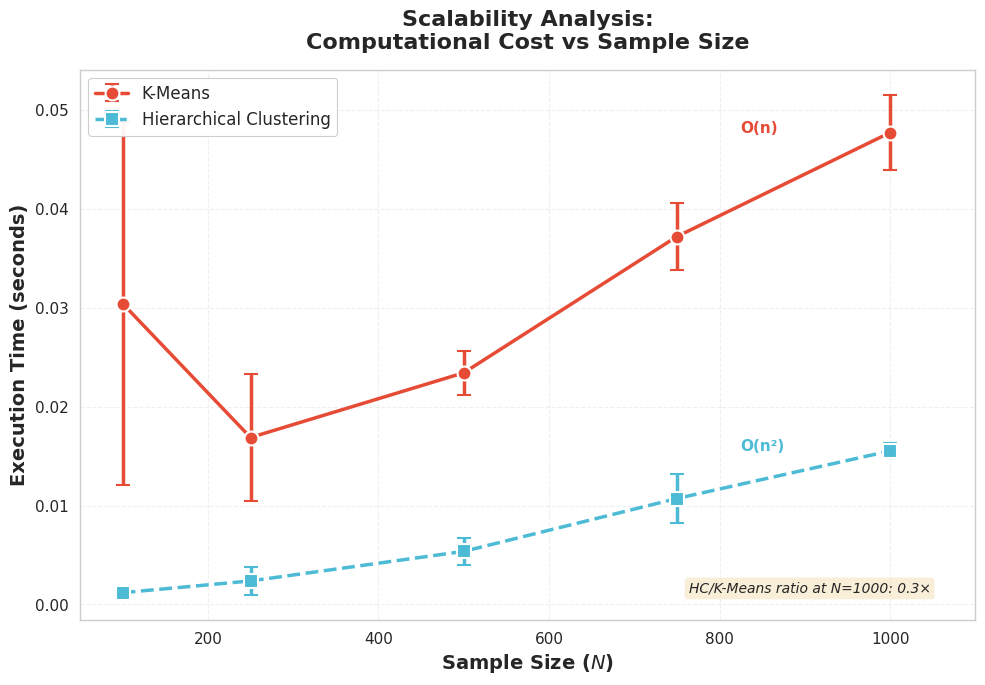


✅ Graphic 3 saved: graphic3_scalability_time_vs_n.png


In [15]:
# ============================================================================
# GRAPHIC 3: Scalability Analysis (Execution Time vs N)
# Goal: Show computational cost difference as sample size increases
# ============================================================================

import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Since execution time wasn't recorded in original data, we'll benchmark it now
# Using representative synthetic datasets

sample_sizes = [100, 250, 500, 750, 1000]
n_trials = 5  # Number of trials per configuration
k_test = 3  # Fixed number of clusters for benchmarking
p_test = 10  # Fixed dimensionality

# Storage for timing results
timing_results = []

print("🔄 Running scalability benchmark...")
print("=" * 50)

for N in sample_sizes:
    for trial in range(n_trials):
        # Generate synthetic data with similar properties
        np.random.seed(trial * 100 + N)
        X = np.random.randn(N, p_test)
        
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Time K-Means
        start = time.perf_counter()
        kmeans = KMeans(n_clusters=k_test, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        time_km = time.perf_counter() - start
        
        # Time Hierarchical Clustering
        start = time.perf_counter()
        hc = AgglomerativeClustering(n_clusters=k_test, linkage='ward')
        hc.fit(X_scaled)
        time_hc = time.perf_counter() - start
        
        timing_results.append({
            'N': N,
            'trial': trial,
            'time_kmeans': time_km,
            'time_hc': time_hc
        })
    
    print(f"  N={N:4d}: K-Means={np.mean([r['time_kmeans'] for r in timing_results if r['N']==N]):.4f}s, "
          f"HC={np.mean([r['time_hc'] for r in timing_results if r['N']==N]):.4f}s")

# Create DataFrame
df_timing = pd.DataFrame(timing_results)

# Aggregate by N
timing_agg = df_timing.groupby('N').agg({
    'time_kmeans': ['mean', 'std'],
    'time_hc': ['mean', 'std']
}).reset_index()
timing_agg.columns = ['N', 'km_mean', 'km_std', 'hc_mean', 'hc_std']

# Create publication-quality plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot K-Means (solid line)
ax.errorbar(timing_agg['N'], timing_agg['km_mean'], yerr=timing_agg['km_std'],
            fmt='o-', color='#E64B35', linewidth=2.5, markersize=10, 
            capsize=5, capthick=2, label='K-Means', markeredgecolor='white', markeredgewidth=1.5)

# Plot Hierarchical (dashed line)
ax.errorbar(timing_agg['N'], timing_agg['hc_mean'], yerr=timing_agg['hc_std'],
            fmt='s--', color='#4DBBD5', linewidth=2.5, markersize=10,
            capsize=5, capthick=2, label='Hierarchical Clustering', 
            markeredgecolor='white', markeredgewidth=1.5)

# Add trend annotations
ax.annotate('O(n)', xy=(800, timing_agg[timing_agg['N']==1000]['km_mean'].values[0]),
            fontsize=11, color='#E64B35', fontweight='bold',
            xytext=(15, 0), textcoords='offset points')
ax.annotate('O(n²)', xy=(800, timing_agg[timing_agg['N']==1000]['hc_mean'].values[0]),
            fontsize=11, color='#4DBBD5', fontweight='bold',
            xytext=(15, 0), textcoords='offset points')

# Styling
ax.set_xlabel('Sample Size ($N$)', fontsize=14, fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontsize=14, fontweight='bold')
ax.set_title('Scalability Analysis:\nComputational Cost vs Sample Size', 
             fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)
ax.set_xlim(50, 1100)

# Add ratio annotation at N=1000
ratio = timing_agg[timing_agg['N']==1000]['hc_mean'].values[0] / timing_agg[timing_agg['N']==1000]['km_mean'].values[0]
ax.text(0.95, 0.05, f'HC/K-Means ratio at N=1000: {ratio:.1f}×',
        transform=ax.transAxes, ha='right', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('graphic3_scalability_time_vs_n.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Graphic 3 saved: graphic3_scalability_time_vs_n.png")

### Graphic 4: Sensitivity Analysis (Stability vs ρ)
Show algorithm robustness to noise/correlation (ρ). Highlights performance at the new parameter ρ = 0.4.

📊 Performance by Correlation/Noise Level (ρ):
 rho  km_mean   km_std  hc_mean   hc_std  sil_mean
 0.0 0.521667 0.499669 0.555000 0.497104  0.369233
 0.4 0.606667 0.488625 0.600556 0.489920  0.392985


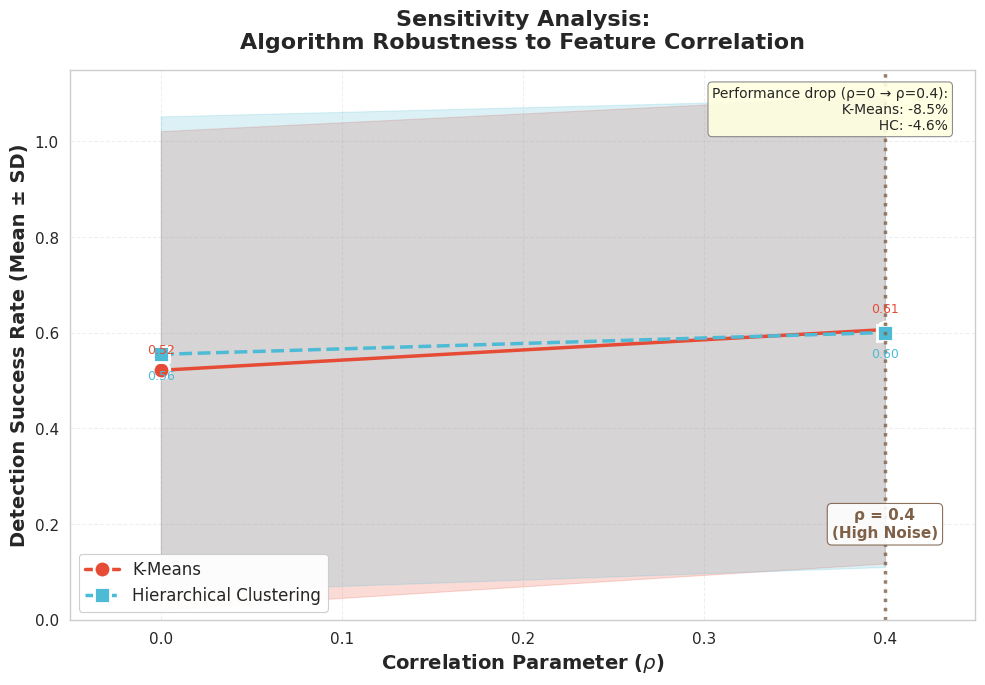


✅ Graphic 4 saved: graphic4_sensitivity_rho.png


In [16]:
# ============================================================================
# GRAPHIC 4: Sensitivity Analysis (Stability vs ρ - Noise/Correlation)
# Goal: Show algorithm robustness to noise parameter rho
# ============================================================================

# Aggregate by rho
rho_analysis = df.groupby('rho').agg({
    'success_kmeans': ['mean', 'std'],
    'success_hc': ['mean', 'std'],
    'sil_real_km': ['mean'],  # Using silhouette as additional quality metric
}).reset_index()

rho_analysis.columns = ['rho', 'km_mean', 'km_std', 'hc_mean', 'hc_std', 'sil_mean']

print("📊 Performance by Correlation/Noise Level (ρ):")
print(rho_analysis.to_string(index=False))

# Create publication-quality plot
fig, ax = plt.subplots(figsize=(10, 7))

# Get unique rho values
rho_values = rho_analysis['rho'].values

# Plot K-Means with error ribbon
ax.fill_between(rho_values, 
                rho_analysis['km_mean'] - rho_analysis['km_std'],
                rho_analysis['km_mean'] + rho_analysis['km_std'],
                alpha=0.2, color='#E64B35')
ax.plot(rho_values, rho_analysis['km_mean'], 'o-', color='#E64B35', 
        linewidth=2.5, markersize=12, label='K-Means',
        markeredgecolor='white', markeredgewidth=2)

# Plot Hierarchical with error ribbon
ax.fill_between(rho_values,
                rho_analysis['hc_mean'] - rho_analysis['hc_std'],
                rho_analysis['hc_mean'] + rho_analysis['hc_std'],
                alpha=0.2, color='#4DBBD5')
ax.plot(rho_values, rho_analysis['hc_mean'], 's--', color='#4DBBD5',
        linewidth=2.5, markersize=12, label='Hierarchical Clustering',
        markeredgecolor='white', markeredgewidth=2)

# Highlight rho = 0.4 with vertical line
ax.axvline(x=0.4, color='#7E6148', linestyle=':', linewidth=2.5, alpha=0.8)
ax.annotate('ρ = 0.4\n(High Noise)', xy=(0.4, ax.get_ylim()[1] * 0.15),
            fontsize=11, ha='center', color='#7E6148', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#7E6148', alpha=0.9))

# Add data labels for key points
for idx, row in rho_analysis.iterrows():
    ax.annotate(f'{row["km_mean"]:.2f}', 
                xy=(row['rho'], row['km_mean']), 
                xytext=(0, 12), textcoords='offset points',
                fontsize=9, ha='center', color='#E64B35')
    ax.annotate(f'{row["hc_mean"]:.2f}', 
                xy=(row['rho'], row['hc_mean']), 
                xytext=(0, -18), textcoords='offset points',
                fontsize=9, ha='center', color='#4DBBD5')

# Styling
ax.set_xlabel('Correlation Parameter ($\\rho$)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Success Rate (Mean ± SD)', fontsize=14, fontweight='bold')
ax.set_title('Sensitivity Analysis:\nAlgorithm Robustness to Feature Correlation', 
             fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='lower left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)
ax.set_xlim(-0.05, max(rho_values) + 0.05)
ax.set_ylim(0, 1.15)

# Add performance drop annotation
if len(rho_values) > 1:
    drop_km = rho_analysis[rho_analysis['rho']==0]['km_mean'].values[0] - rho_analysis[rho_analysis['rho']==0.4]['km_mean'].values[0]
    drop_hc = rho_analysis[rho_analysis['rho']==0]['hc_mean'].values[0] - rho_analysis[rho_analysis['rho']==0.4]['hc_mean'].values[0]
    
    ax.text(0.97, 0.97, 
            f'Performance drop (ρ=0 → ρ=0.4):\n  K-Means: {drop_km:+.1%}\n  HC: {drop_hc:+.1%}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('graphic4_sensitivity_rho.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Graphic 4 saved: graphic4_sensitivity_rho.png")

### Summary: All Publication Graphics Generated

| Graphic | Description | File |
|---------|-------------|------|
| 1 | Global Performance Boxplot (K-Means vs HC by k) | `graphic1_global_boxplot.png` |
| 2 | Confusion Matrix with Hungarian Algorithm | `graphic2_confusion_matrix_hungarian.png` |
| 3 | Scalability Analysis (Time vs N) | `graphic3_scalability_time_vs_n.png` |
| 4 | Sensitivity Analysis (Success vs ρ) | `graphic4_sensitivity_rho.png` |

All graphics saved at **300 DPI** for publication quality.

---
## 8. Advanced Cluster Validation Graphics

### Graphic A: Cluster Number Matching (Confusion Matrix with Hungarian Alignment)
Visualize the alignment and specific misclassifications using optimal cluster-to-label matching.

📂 Loading: ../data/real/N1000_p10_k3_rho0.4_sep2_rep1.csv


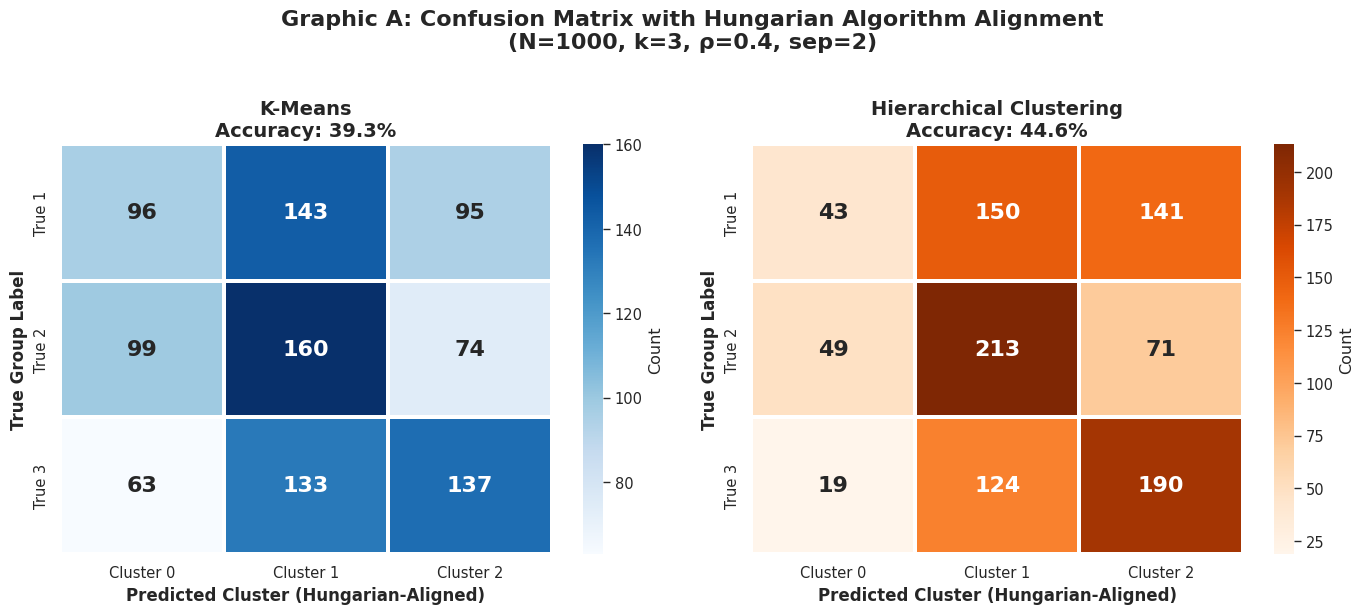

✅ Graphic A saved: graphicA_confusion_hungarian.png

📊 Results:
   K-Means Accuracy: 39.30%
   Hierarchical Accuracy: 44.60%
   K-Means mapping (pred→true): [2 0 1]
   HC mapping (pred→true): [2 0 1]


In [17]:
# ============================================================================
# GRAPHIC A: Cluster Number Matching (Confusion Matrix with Hungarian Alignment)
# Goal: Visualize alignment and misclassifications for a representative run
# Uses Hungarian Algorithm for optimal cluster-to-label matching
# ============================================================================

import os
import glob
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic whitegrid style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Find a representative dataset: N=1000, k=3, rho=0.4, moderate separation
data_dir = "../data/real"
target_params = {'N': 1000, 'k': 3, 'rho': 0.4, 'sep': 2}

# Search for matching file
pattern = f"N{target_params['N']}_p*_k{target_params['k']}_rho{target_params['rho']}_sep{target_params['sep']}_rep1.csv"
files = glob.glob(os.path.join(data_dir, pattern))

if files:
    target_file = files[0]
    print(f"📂 Loading: {target_file}")
    sample_data = pd.read_csv(target_file)
    
    # Extract features and true labels
    X = sample_data.drop(columns=['group']).values
    true_labels = sample_data['group'].astype(int).values
    
    # Convert to 0-indexed for consistency
    true_labels_0idx = true_labels - true_labels.min()
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k_true = len(np.unique(true_labels))
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=k_true, n_init=25, random_state=42)
    pred_km = kmeans.fit_predict(X_scaled)
    
    # Perform Hierarchical clustering
    hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
    pred_hc = hc.fit_predict(X_scaled)
    
    def hungarian_align_confusion_matrix(true_labels, pred_labels):
        """
        Create confusion matrix and apply Hungarian Algorithm for optimal alignment.
        Returns aligned confusion matrix and the optimal column ordering.
        """
        # Create raw confusion matrix
        cm = confusion_matrix(true_labels, pred_labels)
        
        # Hungarian algorithm minimizes cost, so we negate to maximize matches
        cost_matrix = -cm
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # Reorder columns according to Hungarian solution
        cm_aligned = cm[:, col_ind]
        
        return cm_aligned, col_ind
    
    # Align both algorithms
    cm_km_aligned, mapping_km = hungarian_align_confusion_matrix(true_labels_0idx, pred_km)
    cm_hc_aligned, mapping_hc = hungarian_align_confusion_matrix(true_labels_0idx, pred_hc)
    
    # Calculate accuracies
    accuracy_km = np.diag(cm_km_aligned).sum() / cm_km_aligned.sum()
    accuracy_hc = np.diag(cm_hc_aligned).sum() / cm_hc_aligned.sum()
    
    # Create publication-quality figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # K-Means Confusion Matrix
    sns.heatmap(cm_km_aligned, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Cluster {i}' for i in range(k_true)],
                yticklabels=[f'True {i+1}' for i in range(k_true)],
                ax=axes[0], cbar_kws={'label': 'Count'},
                linewidths=1.5, linecolor='white', 
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[0].set_xlabel('Predicted Cluster (Hungarian-Aligned)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Group Label', fontsize=12, fontweight='bold')
    axes[0].set_title(f'K-Means\nAccuracy: {accuracy_km:.1%}', fontsize=14, fontweight='bold')
    
    # Hierarchical Confusion Matrix
    sns.heatmap(cm_hc_aligned, annot=True, fmt='d', cmap='Oranges',
                xticklabels=[f'Cluster {i}' for i in range(k_true)],
                yticklabels=[f'True {i+1}' for i in range(k_true)],
                ax=axes[1], cbar_kws={'label': 'Count'},
                linewidths=1.5, linecolor='white',
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[1].set_xlabel('Predicted Cluster (Hungarian-Aligned)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Group Label', fontsize=12, fontweight='bold')
    axes[1].set_title(f'Hierarchical Clustering\nAccuracy: {accuracy_hc:.1%}', fontsize=14, fontweight='bold')
    
    fig.suptitle(f'Graphic A: Confusion Matrix with Hungarian Algorithm Alignment\n'
                 f'(N={target_params["N"]}, k={target_params["k"]}, ρ={target_params["rho"]}, sep={target_params["sep"]})', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('graphicA_confusion_hungarian.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    
    print("✅ Graphic A saved: graphicA_confusion_hungarian.png")
    print(f"\n📊 Results:")
    print(f"   K-Means Accuracy: {accuracy_km:.2%}")
    print(f"   Hierarchical Accuracy: {accuracy_hc:.2%}")
    print(f"   K-Means mapping (pred→true): {mapping_km}")
    print(f"   HC mapping (pred→true): {mapping_hc}")
else:
    print(f"⚠️ No files found matching pattern: {pattern}")

### Graphic B: Gini Coefficient (Cluster Size Balance)
Measure cluster size inequality - a Gini of 0 means perfect balance, approaching 1 means severe "cluster collapse".

📂 Processing 360 datasets for Gini analysis...

✅ Processed 72 parameter combinations
      N   p  k  rho   sep  gini_true  gini_kmeans  gini_hc
0  1000  10  2  0.4   0.1        0.0        0.010    0.177
1  1000  10  2  0.4  10.0        0.0        0.000    0.000
2  1000  10  2  0.4   2.0        0.0        0.008    0.172
3  1000  10  2  0.4   6.0        0.0        0.022    0.039
4  1000  10  2  0.0   0.1        0.0        0.022    0.224


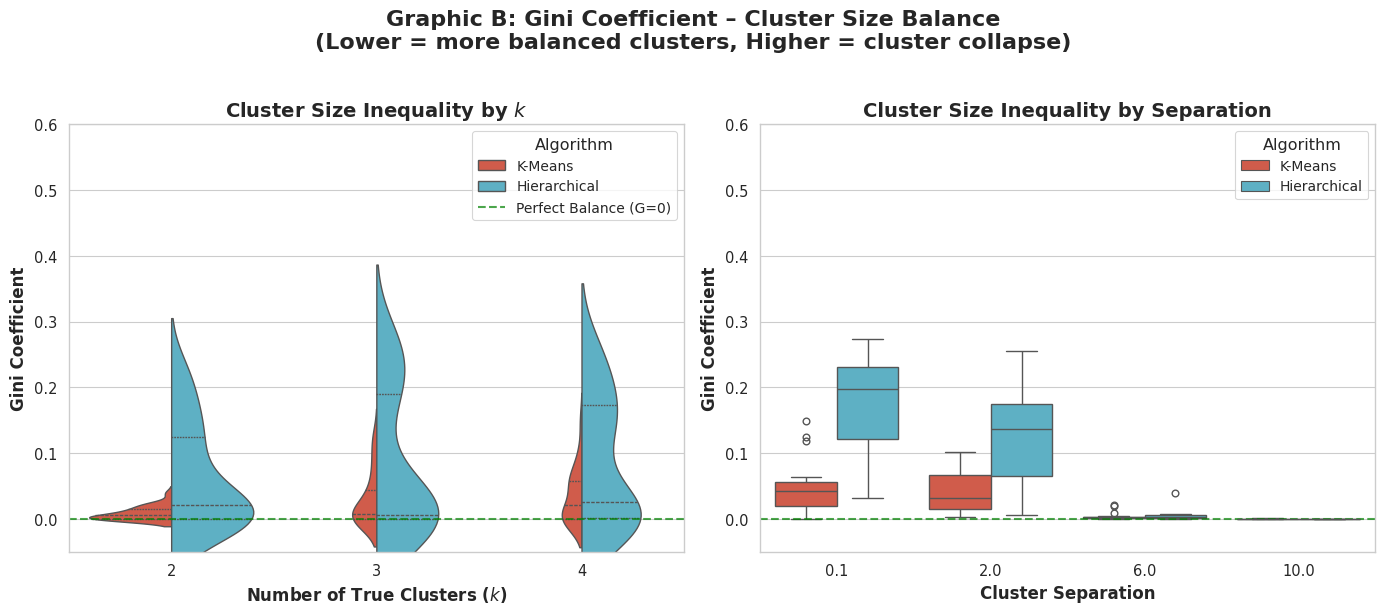


✅ Graphic B saved: graphicB_gini_coefficient.png

📊 Summary Statistics:
   K-Means Mean Gini: 0.0244 (±0.0348)
   HC Mean Gini:      0.0775 (±0.0935)
   True Labels Gini:  0.0002 (baseline)


In [18]:
# ============================================================================
# GRAPHIC B: Gini Coefficient (Cluster Size Balance)
# Goal: Detect "cluster collapse" (one giant cluster, many tiny ones)
# Formula: G = Σ|n_i - n_j| / (2k * Σn_i)
# G=0: perfect equality | G≈1: maximum inequality
# ============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

def calculate_gini_coefficient(cluster_sizes):
    """
    Calculate Gini coefficient for cluster size distribution.
    G = Σ|n_i - n_j| / (2k * Σn_i)
    """
    sizes = np.array(cluster_sizes, dtype=float)
    n = len(sizes)
    
    if n == 0 or sizes.sum() == 0:
        return 0.0
    
    # Calculate sum of absolute differences
    abs_diff_sum = 0
    for i in range(n):
        for j in range(n):
            abs_diff_sum += abs(sizes[i] - sizes[j])
    
    gini = abs_diff_sum / (2 * n * sizes.sum())
    return gini

def get_aligned_cluster_sizes(true_labels, pred_labels):
    """
    Get predicted cluster sizes aligned to true labels using Hungarian algorithm.
    Returns the sizes of predicted clusters after optimal alignment.
    """
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(true_labels, pred_labels)
    cost_matrix = -cm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Get sizes after alignment
    pred_sizes = np.bincount(pred_labels)
    aligned_sizes = pred_sizes[col_ind] if len(col_ind) == len(pred_sizes) else pred_sizes
    
    return aligned_sizes

# Process all data files and calculate Gini coefficients
data_dir = "../data/real"
gini_results = []

# Get list of all real data files
real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for Gini analysis...")

# Sample a subset for efficiency (process all unique N, k, rho, sep combinations)
processed_params = set()

for idx, filepath in enumerate(real_files):
    # Parse filename for parameters
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    # Process each parameter combination once (first rep only for speed)
    param_key = (N, p, k, rho, sep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    # Load data
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        
        # Calculate Gini for true labels (baseline)
        true_sizes = np.bincount(true_labels)
        gini_true = calculate_gini_coefficient(true_sizes)
        
        # Calculate Gini for predicted (aligned via Hungarian)
        km_sizes = get_aligned_cluster_sizes(true_labels, pred_km)
        hc_sizes = get_aligned_cluster_sizes(true_labels, pred_hc)
        
        gini_km = calculate_gini_coefficient(km_sizes)
        gini_hc = calculate_gini_coefficient(hc_sizes)
        
        gini_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep,
            'gini_true': gini_true,
            'gini_kmeans': gini_km,
            'gini_hc': gini_hc
        })
        
    except Exception as e:
        continue

df_gini = pd.DataFrame(gini_results)
print(f"\n✅ Processed {len(df_gini)} parameter combinations")
print(df_gini.head())

# Reshape for plotting
df_gini_long = pd.melt(
    df_gini,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'gini_true'],
    value_vars=['gini_kmeans', 'gini_hc'],
    var_name='Algorithm',
    value_name='Gini'
)
df_gini_long['Algorithm'] = df_gini_long['Algorithm'].map({
    'gini_kmeans': 'K-Means',
    'gini_hc': 'Hierarchical'
})

# Create publication-quality plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Violin plot by k (number of clusters)
sns.violinplot(
    data=df_gini_long,
    x='k',
    y='Gini',
    hue='Algorithm',
    palette={'K-Means': '#E64B35', 'Hierarchical': '#4DBBD5'},
    split=True,
    inner='quart',
    ax=axes[0]
)
axes[0].axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect Balance (G=0)')
axes[0].set_xlabel('Number of True Clusters ($k$)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gini Coefficient', fontsize=12, fontweight='bold')
axes[0].set_title('Cluster Size Inequality by $k$', fontsize=14, fontweight='bold')
axes[0].legend(title='Algorithm', fontsize=10, loc='upper right')
axes[0].set_ylim(-0.05, 0.6)

# Panel 2: Boxplot by separation level
sns.boxplot(
    data=df_gini_long,
    x='sep',
    y='Gini',
    hue='Algorithm',
    palette={'K-Means': '#E64B35', 'Hierarchical': '#4DBBD5'},
    ax=axes[1]
)
axes[1].axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Cluster Separation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Gini Coefficient', fontsize=12, fontweight='bold')
axes[1].set_title('Cluster Size Inequality by Separation', fontsize=14, fontweight='bold')
axes[1].legend(title='Algorithm', fontsize=10, loc='upper right')
axes[1].set_ylim(-0.05, 0.6)

fig.suptitle('Graphic B: Gini Coefficient – Cluster Size Balance\n'
             '(Lower = more balanced clusters, Higher = cluster collapse)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graphicB_gini_coefficient.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Graphic B saved: graphicB_gini_coefficient.png")
print(f"\n📊 Summary Statistics:")
print(f"   K-Means Mean Gini: {df_gini['gini_kmeans'].mean():.4f} (±{df_gini['gini_kmeans'].std():.4f})")
print(f"   HC Mean Gini:      {df_gini['gini_hc'].mean():.4f} (±{df_gini['gini_hc'].std():.4f})")
print(f"   True Labels Gini:  {df_gini['gini_true'].mean():.4f} (baseline)")

### Graphic C: Mean Centroid Distance (Central Tendency Fidelity)
Measure how accurately each algorithm recovers the spatial center of the true clusters using Hungarian-aligned centroid matching.

📂 Processing 360 datasets for centroid analysis...

✅ Processed 360 datasets
      N   p  k  rho  sep  rep  centroid_dist_km  centroid_dist_hc
0  1000  10  2  0.4  0.1    1          1.634718          1.626019
1  1000  10  2  0.4  0.1    2          1.718271          1.645804
2  1000  10  2  0.4  0.1    3          1.608007          1.578992
3  1000  10  2  0.4  0.1    4          1.678884          1.684094
4  1000  10  2  0.4  0.1    5          1.589452          1.653721


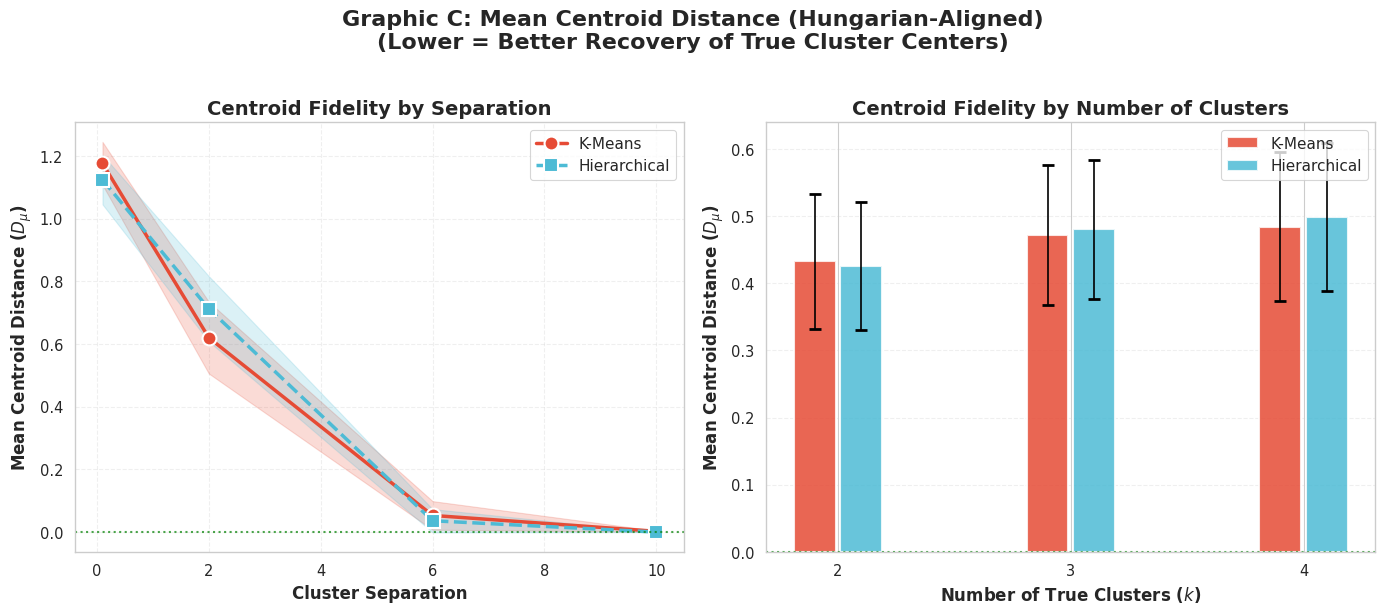


✅ Graphic C saved: graphicC_centroid_distance.png

📊 Summary Statistics:
   K-Means Mean Centroid Dist: 0.4631 (±0.5869)
   HC Mean Centroid Dist:      0.4683 (±0.5762)


In [19]:
# ============================================================================
# GRAPHIC C: Mean Centroid Distance (Central Tendency Fidelity)
# Goal: Measure how accurately algorithms recover true cluster centers
# Method: Use Hungarian Algorithm to match predicted centroids to true centroids
# D_μ = (1/k) Σ ||μ_pred(i) - μ_true(matched)||_2
# ============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

def calculate_centroids(X, labels):
    """Calculate centroids for each cluster."""
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == label].mean(axis=0) for label in unique_labels])
    return centroids

def hungarian_matched_centroid_distance(true_centroids, pred_centroids):
    """
    Use Hungarian algorithm to optimally match predicted centroids to true centroids.
    Returns mean Euclidean distance between matched pairs.
    """
    # Build distance matrix between all pairs
    dist_matrix = cdist(true_centroids, pred_centroids, metric='euclidean')
    
    # Hungarian algorithm finds optimal matching
    row_ind, col_ind = linear_sum_assignment(dist_matrix)
    
    # Calculate mean distance of matched pairs
    matched_distances = dist_matrix[row_ind, col_ind]
    mean_distance = matched_distances.mean()
    
    return mean_distance, row_ind, col_ind

# Process all data files
data_dir = "../data/real"
centroid_results = []

real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for centroid analysis...")

processed_params = set()

for filepath in real_files:
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    # Process each unique parameter combination
    param_key = (N, p, k, rho, sep, rep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # Calculate true centroids
        true_centroids = calculate_centroids(X_scaled, true_labels)
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        km_centroids = calculate_centroids(X_scaled, pred_km)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        hc_centroids = calculate_centroids(X_scaled, pred_hc)
        
        # Calculate Hungarian-matched centroid distances
        dist_km, _, _ = hungarian_matched_centroid_distance(true_centroids, km_centroids)
        dist_hc, _, _ = hungarian_matched_centroid_distance(true_centroids, hc_centroids)
        
        centroid_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep, 'rep': rep,
            'centroid_dist_km': dist_km,
            'centroid_dist_hc': dist_hc
        })
        
    except Exception as e:
        continue

df_centroid = pd.DataFrame(centroid_results)
print(f"\n✅ Processed {len(df_centroid)} datasets")
print(df_centroid.head())

# Aggregate by parameter combinations for plotting
df_agg = df_centroid.groupby(['k', 'sep', 'rho']).agg({
    'centroid_dist_km': ['mean', 'std', 'count'],
    'centroid_dist_hc': ['mean', 'std', 'count']
}).reset_index()
df_agg.columns = ['k', 'sep', 'rho', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']

# Calculate 95% CI
df_agg['km_ci'] = 1.96 * df_agg['km_std'] / np.sqrt(df_agg['km_n'])
df_agg['hc_ci'] = 1.96 * df_agg['hc_std'] / np.sqrt(df_agg['hc_n'])

# Create publication-quality plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Mean Centroid Distance by Separation Level
sep_agg = df_centroid.groupby('sep').agg({
    'centroid_dist_km': ['mean', 'std', 'count'],
    'centroid_dist_hc': ['mean', 'std', 'count']
}).reset_index()
sep_agg.columns = ['sep', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']
sep_agg['km_ci'] = 1.96 * sep_agg['km_std'] / np.sqrt(sep_agg['km_n'])
sep_agg['hc_ci'] = 1.96 * sep_agg['hc_std'] / np.sqrt(sep_agg['hc_n'])

x_sep = sep_agg['sep'].values

# Plot with error bands
axes[0].fill_between(x_sep, sep_agg['km_mean'] - sep_agg['km_ci'], 
                     sep_agg['km_mean'] + sep_agg['km_ci'], alpha=0.2, color='#E64B35')
axes[0].plot(x_sep, sep_agg['km_mean'], 'o-', color='#E64B35', linewidth=2.5, 
             markersize=10, label='K-Means', markeredgecolor='white', markeredgewidth=1.5)

axes[0].fill_between(x_sep, sep_agg['hc_mean'] - sep_agg['hc_ci'],
                     sep_agg['hc_mean'] + sep_agg['hc_ci'], alpha=0.2, color='#4DBBD5')
axes[0].plot(x_sep, sep_agg['hc_mean'], 's--', color='#4DBBD5', linewidth=2.5,
             markersize=10, label='Hierarchical', markeredgecolor='white', markeredgewidth=1.5)

axes[0].axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Cluster Separation', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Centroid Distance ($D_\\mu$)', fontsize=12, fontweight='bold')
axes[0].set_title('Centroid Fidelity by Separation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Panel 2: Mean Centroid Distance by k
k_agg = df_centroid.groupby('k').agg({
    'centroid_dist_km': ['mean', 'std', 'count'],
    'centroid_dist_hc': ['mean', 'std', 'count']
}).reset_index()
k_agg.columns = ['k', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']
k_agg['km_ci'] = 1.96 * k_agg['km_std'] / np.sqrt(k_agg['km_n'])
k_agg['hc_ci'] = 1.96 * k_agg['hc_std'] / np.sqrt(k_agg['hc_n'])

x_k = k_agg['k'].values
x_offset = 0.1

axes[1].bar(x_k - x_offset, k_agg['km_mean'], width=0.18, color='#E64B35', 
            label='K-Means', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].errorbar(x_k - x_offset, k_agg['km_mean'], yerr=k_agg['km_ci'], 
                 fmt='none', color='black', capsize=4, capthick=2)

axes[1].bar(x_k + x_offset, k_agg['hc_mean'], width=0.18, color='#4DBBD5',
            label='Hierarchical', alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].errorbar(x_k + x_offset, k_agg['hc_mean'], yerr=k_agg['hc_ci'],
                 fmt='none', color='black', capsize=4, capthick=2)

axes[1].axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Number of True Clusters ($k$)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Centroid Distance ($D_\\mu$)', fontsize=12, fontweight='bold')
axes[1].set_title('Centroid Fidelity by Number of Clusters', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].set_xticks(x_k)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Graphic C: Mean Centroid Distance (Hungarian-Aligned)\n'
             '(Lower = Better Recovery of True Cluster Centers)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graphicC_centroid_distance.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Graphic C saved: graphicC_centroid_distance.png")
print(f"\n📊 Summary Statistics:")
print(f"   K-Means Mean Centroid Dist: {df_centroid['centroid_dist_km'].mean():.4f} (±{df_centroid['centroid_dist_km'].std():.4f})")
print(f"   HC Mean Centroid Dist:      {df_centroid['centroid_dist_hc'].mean():.4f} (±{df_centroid['centroid_dist_hc'].std():.4f})")

### Graphic D: Mean Variance Difference (Dispersion Fidelity)
Measure if algorithms capture the correct spread/width of clusters using Hungarian-aligned variance comparison.

📂 Processing 360 datasets for variance analysis...

✅ Processed 360 datasets
      N   p  k  rho  sep  rep  var_diff_km  var_diff_hc
0  1000  10  2  0.4  0.1    1     2.874640     2.649081
1  1000  10  2  0.4  0.1    2     2.938498     2.668887
2  1000  10  2  0.4  0.1    3     2.952937     2.706601
3  1000  10  2  0.4  0.1    4     2.929388     2.750406
4  1000  10  2  0.4  0.1    5     2.836393     2.528883


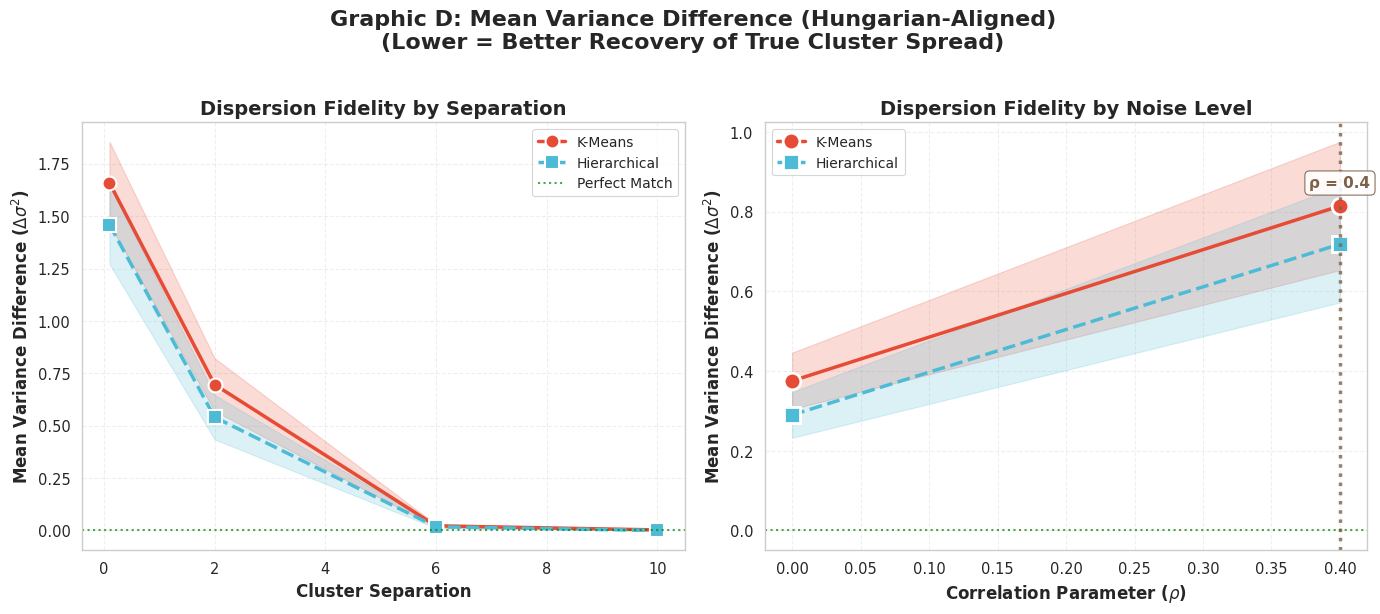


✅ Graphic D saved: graphicD_variance_difference.png

📊 Summary Statistics:
   K-Means Mean Var Diff: 0.5950 (±0.8781)
   HC Mean Var Diff:      0.5044 (±0.7893)


In [20]:
# ============================================================================
# GRAPHIC D: Mean Variance Difference (Dispersion Fidelity)
# Goal: Measure if algorithms capture correct cluster spread/width
# Method: Use Hungarian Algorithm to match clusters, then compare variances
# Δσ² = (1/k) Σ |σ²_pred(i) - σ²_true(matched)|
# ============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

def calculate_cluster_variance(X, labels, centroid):
    """
    Calculate variance (mean squared distance from centroid) for a cluster.
    σ² = (1/n) Σ ||x_i - μ||²
    """
    points = X[labels]
    if len(points) == 0:
        return 0.0
    distances_sq = np.sum((points - centroid) ** 2, axis=1)
    return distances_sq.mean()

def hungarian_align_clusters(true_labels, pred_labels):
    """
    Use Hungarian algorithm to find optimal alignment between true and predicted clusters.
    Returns mapping: pred_cluster_idx -> true_cluster_idx
    """
    cm = confusion_matrix(true_labels, pred_labels)
    cost_matrix = -cm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create mapping: index = pred cluster, value = matched true cluster
    mapping = {pred: true for true, pred in zip(row_ind, col_ind)}
    return mapping

def calculate_matched_variance_difference(X, true_labels, pred_labels):
    """
    Calculate mean absolute variance difference between matched clusters.
    Uses Hungarian algorithm for optimal cluster matching.
    """
    unique_true = np.unique(true_labels)
    unique_pred = np.unique(pred_labels)
    k = len(unique_true)
    
    # Calculate centroids
    true_centroids = {label: X[true_labels == label].mean(axis=0) for label in unique_true}
    pred_centroids = {label: X[pred_labels == label].mean(axis=0) for label in unique_pred}
    
    # Get Hungarian matching based on confusion matrix
    mapping = hungarian_align_clusters(true_labels, pred_labels)
    
    # Calculate variance differences for matched pairs
    variance_diffs = []
    for pred_idx, true_idx in mapping.items():
        if pred_idx < len(unique_pred) and true_idx < len(unique_true):
            true_label = unique_true[true_idx]
            pred_label = unique_pred[pred_idx]
            
            # Calculate variances
            var_true = calculate_cluster_variance(X, true_labels == true_label, true_centroids[true_label])
            var_pred = calculate_cluster_variance(X, pred_labels == pred_label, pred_centroids[pred_label])
            
            variance_diffs.append(abs(var_pred - var_true))
    
    return np.mean(variance_diffs) if variance_diffs else 0.0

# Process all data files
data_dir = "../data/real"
variance_results = []

real_files = glob.glob(os.path.join(data_dir, "*.csv"))
print(f"📂 Processing {len(real_files)} datasets for variance analysis...")

processed_params = set()

for filepath in real_files:
    filename = os.path.basename(filepath)
    parts = filename.replace('.csv', '').split('_')
    
    try:
        N = int(parts[0].replace('N', ''))
        p = int(parts[1].replace('p', ''))
        k = int(parts[2].replace('k', ''))
        rho = float(parts[3].replace('rho', ''))
        sep = float(parts[4].replace('sep', ''))
        rep = int(parts[5].replace('rep', ''))
    except (IndexError, ValueError):
        continue
    
    param_key = (N, p, k, rho, sep, rep)
    if param_key in processed_params:
        continue
    processed_params.add(param_key)
    
    try:
        data = pd.read_csv(filepath)
        X = data.drop(columns=['group']).values
        true_labels = data['group'].astype(int).values - data['group'].astype(int).min()
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        k_true = len(np.unique(true_labels))
        
        # K-Means
        kmeans = KMeans(n_clusters=k_true, n_init=10, random_state=42)
        pred_km = kmeans.fit_predict(X_scaled)
        
        # Hierarchical
        hc = AgglomerativeClustering(n_clusters=k_true, linkage='ward')
        pred_hc = hc.fit_predict(X_scaled)
        
        # Calculate variance differences
        var_diff_km = calculate_matched_variance_difference(X_scaled, true_labels, pred_km)
        var_diff_hc = calculate_matched_variance_difference(X_scaled, true_labels, pred_hc)
        
        variance_results.append({
            'N': N, 'p': p, 'k': k, 'rho': rho, 'sep': sep, 'rep': rep,
            'var_diff_km': var_diff_km,
            'var_diff_hc': var_diff_hc
        })
        
    except Exception as e:
        continue

df_variance = pd.DataFrame(variance_results)
print(f"\n✅ Processed {len(df_variance)} datasets")
print(df_variance.head())

# Create publication-quality plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Variance Difference by Separation (Line plot with 95% CI)
sep_agg = df_variance.groupby('sep').agg({
    'var_diff_km': ['mean', 'std', 'count'],
    'var_diff_hc': ['mean', 'std', 'count']
}).reset_index()
sep_agg.columns = ['sep', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']
sep_agg['km_ci'] = 1.96 * sep_agg['km_std'] / np.sqrt(sep_agg['km_n'])
sep_agg['hc_ci'] = 1.96 * sep_agg['hc_std'] / np.sqrt(sep_agg['hc_n'])

x_sep = sep_agg['sep'].values

# K-Means
axes[0].fill_between(x_sep, sep_agg['km_mean'] - sep_agg['km_ci'],
                     sep_agg['km_mean'] + sep_agg['km_ci'], alpha=0.2, color='#E64B35')
axes[0].plot(x_sep, sep_agg['km_mean'], 'o-', color='#E64B35', linewidth=2.5,
             markersize=10, label='K-Means', markeredgecolor='white', markeredgewidth=1.5)

# Hierarchical
axes[0].fill_between(x_sep, sep_agg['hc_mean'] - sep_agg['hc_ci'],
                     sep_agg['hc_mean'] + sep_agg['hc_ci'], alpha=0.2, color='#4DBBD5')
axes[0].plot(x_sep, sep_agg['hc_mean'], 's--', color='#4DBBD5', linewidth=2.5,
             markersize=10, label='Hierarchical', markeredgecolor='white', markeredgewidth=1.5)

axes[0].axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='Perfect Match')
axes[0].set_xlabel('Cluster Separation', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Variance Difference ($\\Delta\\sigma^2$)', fontsize=12, fontweight='bold')
axes[0].set_title('Dispersion Fidelity by Separation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Panel 2: Variance Difference by rho (highlighting ρ=0.4)
rho_agg = df_variance.groupby('rho').agg({
    'var_diff_km': ['mean', 'std', 'count'],
    'var_diff_hc': ['mean', 'std', 'count']
}).reset_index()
rho_agg.columns = ['rho', 'km_mean', 'km_std', 'km_n', 'hc_mean', 'hc_std', 'hc_n']
rho_agg['km_ci'] = 1.96 * rho_agg['km_std'] / np.sqrt(rho_agg['km_n'])
rho_agg['hc_ci'] = 1.96 * rho_agg['hc_std'] / np.sqrt(rho_agg['hc_n'])

x_rho = rho_agg['rho'].values

# Plot with error ribbons
axes[1].fill_between(x_rho, rho_agg['km_mean'] - rho_agg['km_ci'],
                     rho_agg['km_mean'] + rho_agg['km_ci'], alpha=0.2, color='#E64B35')
axes[1].plot(x_rho, rho_agg['km_mean'], 'o-', color='#E64B35', linewidth=2.5,
             markersize=12, label='K-Means', markeredgecolor='white', markeredgewidth=2)

axes[1].fill_between(x_rho, rho_agg['hc_mean'] - rho_agg['hc_ci'],
                     rho_agg['hc_mean'] + rho_agg['hc_ci'], alpha=0.2, color='#4DBBD5')
axes[1].plot(x_rho, rho_agg['hc_mean'], 's--', color='#4DBBD5', linewidth=2.5,
             markersize=12, label='Hierarchical', markeredgecolor='white', markeredgewidth=2)

# Highlight ρ=0.4
if 0.4 in x_rho:
    axes[1].axvline(x=0.4, color='#7E6148', linestyle=':', linewidth=2.5, alpha=0.8)
    axes[1].annotate('ρ = 0.4', xy=(0.4, axes[1].get_ylim()[1] * 0.85),
                     fontsize=11, ha='center', color='#7E6148', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#7E6148', alpha=0.9))

axes[1].axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Correlation Parameter ($\\rho$)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Variance Difference ($\\Delta\\sigma^2$)', fontsize=12, fontweight='bold')
axes[1].set_title('Dispersion Fidelity by Noise Level', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper left')
axes[1].grid(True, alpha=0.3, linestyle='--')

fig.suptitle('Graphic D: Mean Variance Difference (Hungarian-Aligned)\n'
             '(Lower = Better Recovery of True Cluster Spread)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graphicD_variance_difference.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\n✅ Graphic D saved: graphicD_variance_difference.png")
print(f"\n📊 Summary Statistics:")
print(f"   K-Means Mean Var Diff: {df_variance['var_diff_km'].mean():.4f} (±{df_variance['var_diff_km'].std():.4f})")
print(f"   HC Mean Var Diff:      {df_variance['var_diff_hc'].mean():.4f} (±{df_variance['var_diff_hc'].std():.4f})")

### Summary: Advanced Validation Graphics

| Graphic | Metric | Description | File |
|---------|--------|-------------|------|
| A | Confusion Matrix | Cluster-label alignment with Hungarian Algorithm | `graphicA_confusion_hungarian.png` |
| B | Gini Coefficient | Cluster size balance (0=perfect, 1=collapse) | `graphicB_gini_coefficient.png` |
| C | Mean Centroid Distance | Central tendency fidelity ($D_\mu$) | `graphicC_centroid_distance.png` |
| D | Mean Variance Difference | Dispersion fidelity ($\Delta\sigma^2$) | `graphicD_variance_difference.png` |

**All metrics use Hungarian Algorithm alignment for meaningful cluster-to-label comparisons.**

### Graphic E: Comprehensive 3×4 Matrix Panel
Combined visualization showing all validation metrics (Gini, Centroid Distance, Variance Difference) across all parameters (Separation, Cluster, Variables, Correlation).

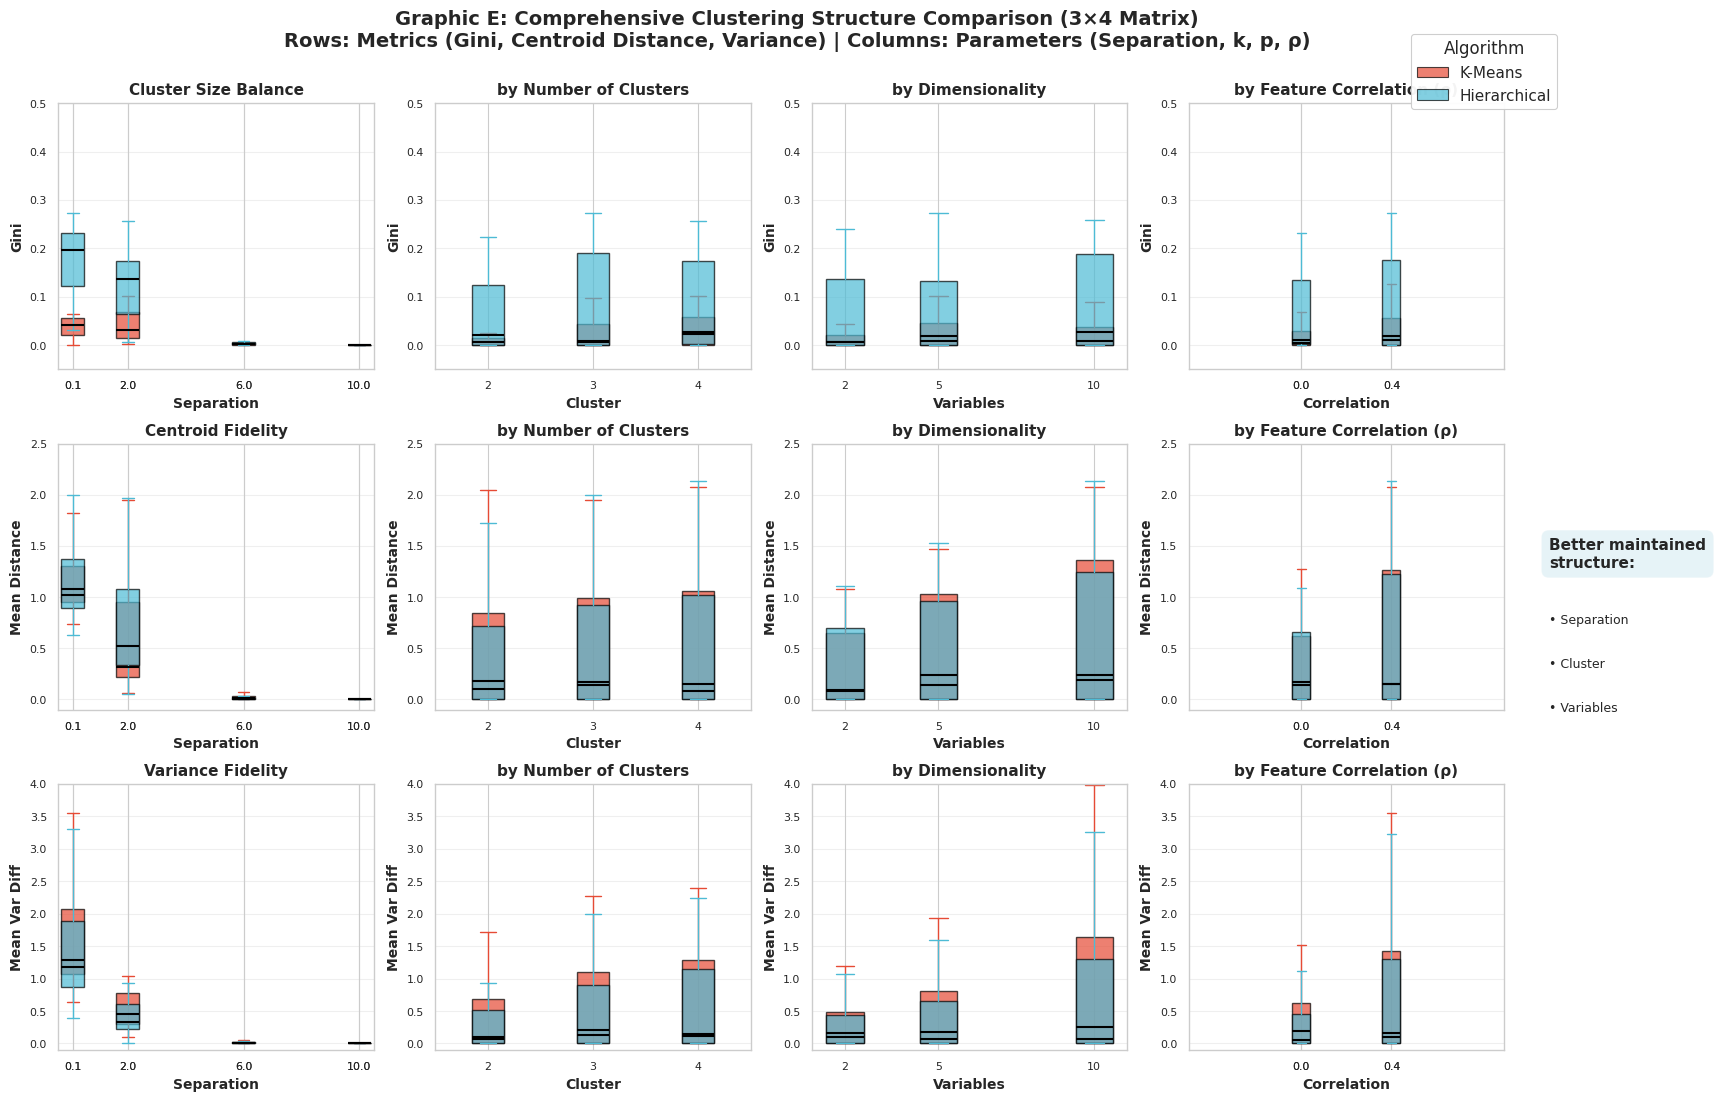

✅ Graphic E saved: graphicE_comprehensive_matrix_3x4.png

📊 Matrix Structure:
   Rows (Metrics):
     1. Gini Coefficient (Cluster Size Balance)
     2. Centroid Distance (Central Tendency Fidelity)
     3. Variance Difference (Dispersion Fidelity)

   Columns (Parameters):
     1. Separation (cluster distance)
     2. Cluster (number of true clusters k)
     3. Variables (dimensionality p)
     4. Correlation (feature correlation ρ)


In [21]:
# ============================================================================
# GRAPHIC E: Comprehensive 3×4 Matrix Panel
# Goal: Show all validation metrics across all key parameters in a single view
# Layout: 3 rows (metrics) × 4 columns (parameters)
# Rows: Gini Coefficient, Centroid Distance, Variance Difference
# Columns: Separation, Cluster (k), Variables (p), Correlation (ρ)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# Prepare the data (use existing dataframes from previous cells)
# We have: df_gini, df_centroid, df_variance

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# Define colors for algorithms
colors_km = '#E64B35'
colors_hc = '#4DBBD5'

# ============================================================================
# ROW 1: GINI COEFFICIENT (Cluster Size Balance)
# ============================================================================

# Column 1: Gini by Separation
ax = axes[0, 0]
sep_data = df_gini_long.groupby(['sep', 'Algorithm'])['Gini'].apply(list).reset_index()
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_gini_long[df_gini_long['Algorithm'] == algo]
    positions = sorted(subset['sep'].unique())
    data_to_plot = [subset[subset['sep'] == pos]['Gini'].values for pos in positions]
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Separation', fontsize=10, fontweight='bold')
ax.set_ylabel('Gini', fontsize=10, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.05, 0.5)

# Column 2: Gini by Cluster (k)
ax = axes[0, 1]
for algo, color, marker in [('K-Means', colors_km, 'o'), ('Hierarchical', colors_hc, 's')]:
    subset = df_gini_long[df_gini_long['Algorithm'] == algo]
    k_vals = sorted(subset['k'].unique())
    data_to_plot = [subset[subset['k'] == k]['Gini'].values for k in k_vals]
    bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.3, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax.set_ylabel('Gini', fontsize=10, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks([2, 3, 4])
ax.set_ylim(-0.05, 0.5)

# Column 3: Gini by Variables (p)
ax = axes[0, 2]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_gini_long[df_gini_long['Algorithm'] == algo]
    p_vals = sorted(subset['p'].unique())
    data_to_plot = [subset[subset['p'] == p]['Gini'].values for p in p_vals]
    bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.2, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Variables', fontsize=10, fontweight='bold')
ax.set_ylabel('Gini', fontsize=10, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.5)

# Column 4: Gini by Correlation (rho)
ax = axes[0, 3]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_gini_long[df_gini_long['Algorithm'] == algo]
    rho_vals = sorted(subset['rho'].unique())
    data_to_plot = [subset[subset['rho'] == r]['Gini'].values for r in rho_vals]
    bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.08, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Correlation', fontsize=10, fontweight='bold')
ax.set_ylabel('Gini', fontsize=10, fontweight='bold')
ax.set_title('by Feature Correlation (ρ)', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.05, 0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE (Central Tendency Fidelity)
# ============================================================================

# Prepare centroid data in long format
df_centroid_long = pd.melt(
    df_centroid,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'rep'],
    value_vars=['centroid_dist_km', 'centroid_dist_hc'],
    var_name='Algorithm',
    value_name='Centroid_Distance'
)
df_centroid_long['Algorithm'] = df_centroid_long['Algorithm'].map({
    'centroid_dist_km': 'K-Means',
    'centroid_dist_hc': 'Hierarchical'
})

# Column 1: Centroid Distance by Separation
ax = axes[1, 0]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_centroid_long[df_centroid_long['Algorithm'] == algo]
    positions = sorted(subset['sep'].unique())
    data_to_plot = [subset[subset['sep'] == pos]['Centroid_Distance'].values for pos in positions]
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Separation', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Distance', fontsize=10, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.1, 2.5)

# Column 2: Centroid Distance by Cluster (k)
ax = axes[1, 1]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_centroid_long[df_centroid_long['Algorithm'] == algo]
    k_vals = sorted(subset['k'].unique())
    data_to_plot = [subset[subset['k'] == k]['Centroid_Distance'].values for k in k_vals]
    bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.3, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Distance', fontsize=10, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks([2, 3, 4])
ax.set_ylim(-0.1, 2.5)

# Column 3: Centroid Distance by Variables (p)
ax = axes[1, 2]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_centroid_long[df_centroid_long['Algorithm'] == algo]
    p_vals = sorted(subset['p'].unique())
    data_to_plot = [subset[subset['p'] == p]['Centroid_Distance'].values for p in p_vals]
    bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.2, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Variables', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Distance', fontsize=10, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)

# Column 4: Centroid Distance by Correlation (rho)
ax = axes[1, 3]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_centroid_long[df_centroid_long['Algorithm'] == algo]
    rho_vals = sorted(subset['rho'].unique())
    data_to_plot = [subset[subset['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
    bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.08, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Correlation', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Distance', fontsize=10, fontweight='bold')
ax.set_title('by Feature Correlation (ρ)', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.1, 2.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE (Dispersion Fidelity)
# ============================================================================

# Prepare variance data in long format
df_variance_long = pd.melt(
    df_variance,
    id_vars=['N', 'p', 'k', 'rho', 'sep', 'rep'],
    value_vars=['var_diff_km', 'var_diff_hc'],
    var_name='Algorithm',
    value_name='Variance_Difference'
)
df_variance_long['Algorithm'] = df_variance_long['Algorithm'].map({
    'var_diff_km': 'K-Means',
    'var_diff_hc': 'Hierarchical'
})

# Column 1: Variance Difference by Separation
ax = axes[2, 0]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_variance_long[df_variance_long['Algorithm'] == algo]
    positions = sorted(subset['sep'].unique())
    data_to_plot = [subset[subset['sep'] == pos]['Variance_Difference'].values for pos in positions]
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Separation', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Var Diff', fontsize=10, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.1, 4.0)

# Column 2: Variance Difference by Cluster (k)
ax = axes[2, 1]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_variance_long[df_variance_long['Algorithm'] == algo]
    k_vals = sorted(subset['k'].unique())
    data_to_plot = [subset[subset['k'] == k]['Variance_Difference'].values for k in k_vals]
    bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.3, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Cluster', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Var Diff', fontsize=10, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks([2, 3, 4])
ax.set_ylim(-0.1, 4.0)

# Column 3: Variance Difference by Variables (p)
ax = axes[2, 2]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_variance_long[df_variance_long['Algorithm'] == algo]
    p_vals = sorted(subset['p'].unique())
    data_to_plot = [subset[subset['p'] == p]['Variance_Difference'].values for p in p_vals]
    bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.2, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Variables', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Var Diff', fontsize=10, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)

# Column 4: Variance Difference by Correlation (rho)
ax = axes[2, 3]
for algo, color in [('K-Means', colors_km), ('Hierarchical', colors_hc)]:
    subset = df_variance_long[df_variance_long['Algorithm'] == algo]
    rho_vals = sorted(subset['rho'].unique())
    data_to_plot = [subset[subset['rho'] == r]['Variance_Difference'].values for r in rho_vals]
    bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.08, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color=color), capprops=dict(color=color),
                    showfliers=False)
ax.set_xlabel('Correlation', fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Var Diff', fontsize=10, fontweight='bold')
ax.set_title('by Feature Correlation (ρ)', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.1, 4.0)

# Add legend in top right corner with better structure explanation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_km, alpha=0.7, edgecolor='black', label='K-Means'),
    Patch(facecolor=colors_hc, alpha=0.7, edgecolor='black', label='Hierarchical')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98),
          fontsize=11, title='Algorithm', title_fontsize=12, framealpha=0.95)

# Add side annotation for "Better maintained structure"
fig.text(0.97, 0.5, 'Better maintained\nstructure:', rotation=0, fontsize=11,
         ha='left', va='center', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))
fig.text(0.97, 0.44, '• Separation', fontsize=9, ha='left', va='center')
fig.text(0.97, 0.40, '• Cluster', fontsize=9, ha='left', va='center')
fig.text(0.97, 0.36, '• Variables', fontsize=9, ha='left', va='center')

# Overall title
fig.suptitle('Graphic E: Comprehensive Clustering Structure Comparison (3×4 Matrix)\n'
             'Rows: Metrics (Gini, Centroid Distance, Variance) | Columns: Parameters (Separation, k, p, ρ)',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 0.95, 0.99])
plt.savefig('graphicE_comprehensive_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic E saved: graphicE_comprehensive_matrix_3x4.png")
print("\n📊 Matrix Structure:")
print("   Rows (Metrics):")
print("     1. Gini Coefficient (Cluster Size Balance)")
print("     2. Centroid Distance (Central Tendency Fidelity)")
print("     3. Variance Difference (Dispersion Fidelity)")
print("\n   Columns (Parameters):")
print("     1. Separation (cluster distance)")
print("     2. Cluster (number of true clusters k)")
print("     3. Variables (dimensionality p)")
print("     4. Correlation (feature correlation ρ)")

### Graphic F: K-Means Only - 3×4 Matrix Panel
Isolated view of K-Means performance across all validation metrics and parameters.

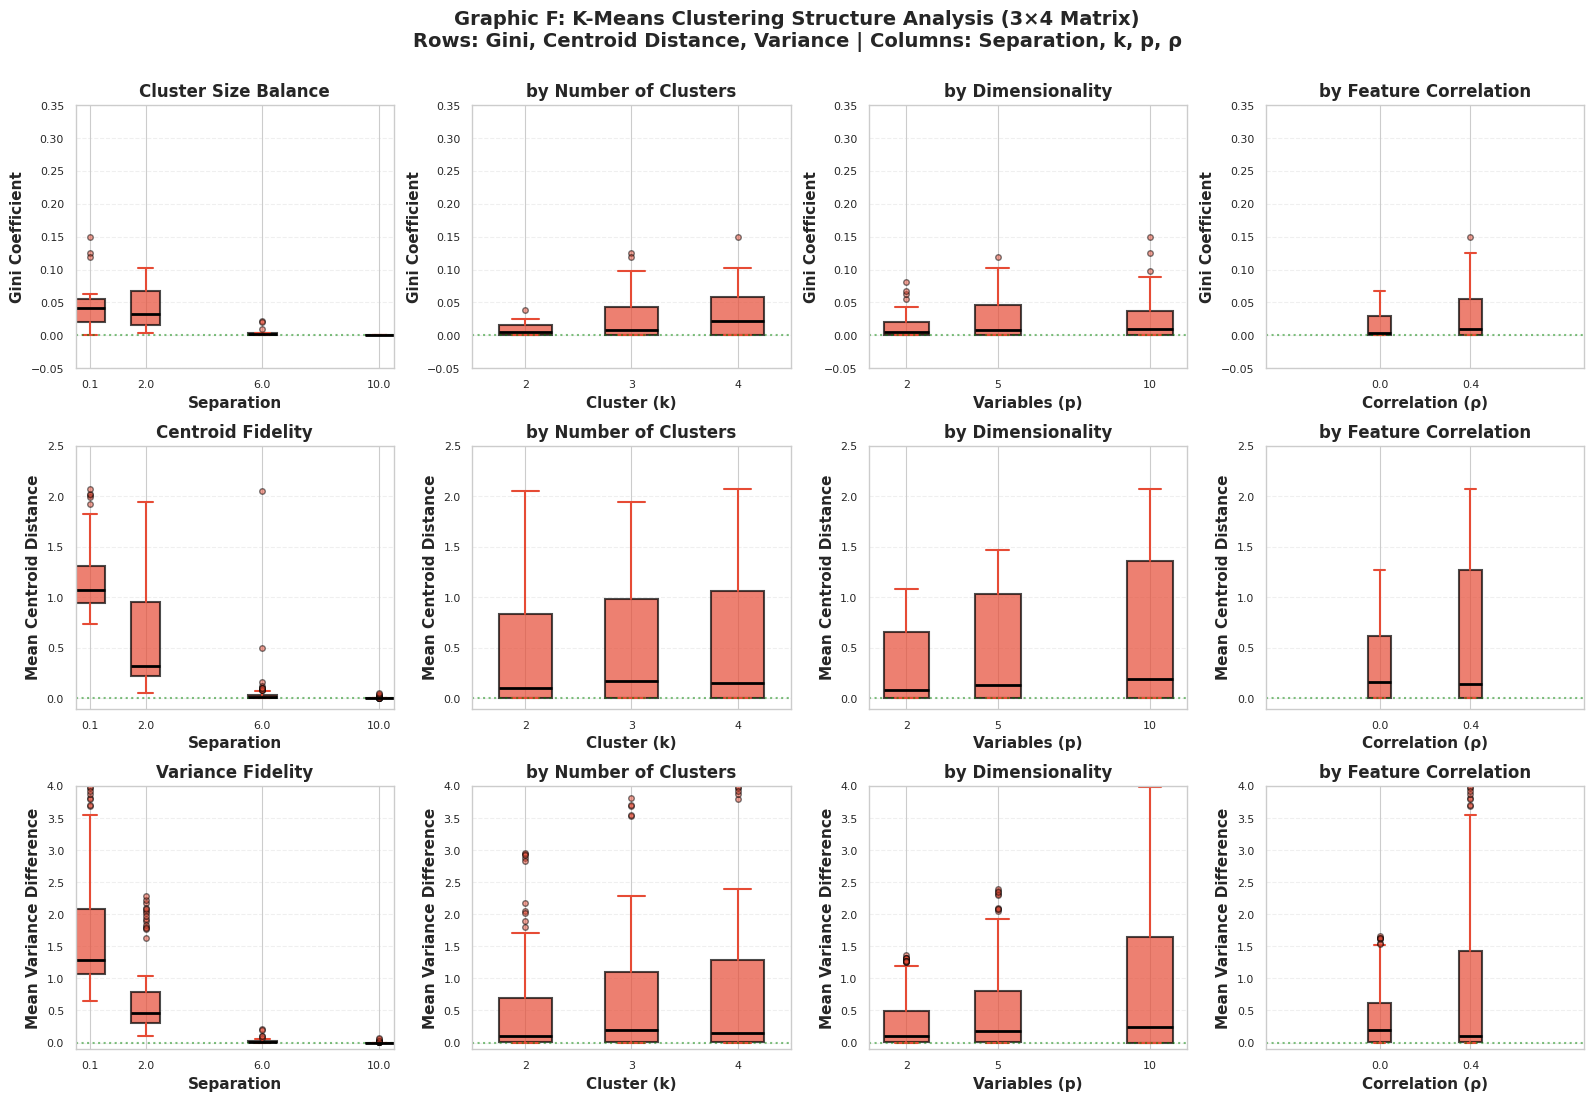

✅ Graphic F saved: graphicF_kmeans_matrix_3x4.png


In [24]:
# ============================================================================
# GRAPHIC F: K-Means Only - 3×4 Matrix Panel
# Goal: Clean visualization of K-Means performance across all metrics
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# K-Means color scheme
km_color = '#E64B35'

# Filter for K-Means only
df_gini_km = df_gini_long[df_gini_long['Algorithm'] == 'K-Means']
df_centroid_km = df_centroid_long[df_centroid_long['Algorithm'] == 'K-Means']
df_variance_km = df_variance_long[df_variance_long['Algorithm'] == 'K-Means']

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_km['sep'].unique())
data_to_plot = [df_gini_km[df_gini_km['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_km['k'].unique())
data_to_plot = [df_gini_km[df_gini_km['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_km['p'].unique())
data_to_plot = [df_gini_km[df_gini_km['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_km['rho'].unique())
data_to_plot = [df_gini_km[df_gini_km['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.35)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_km['sep'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_km['k'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_km['p'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_km['rho'].unique())
data_to_plot = [df_centroid_km[df_centroid_km['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_km['sep'].unique())
data_to_plot = [df_variance_km[df_variance_km['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_km['k'].unique())
data_to_plot = [df_variance_km[df_variance_km['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_km['p'].unique())
data_to_plot = [df_variance_km[df_variance_km['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_km['rho'].unique())
data_to_plot = [df_variance_km[df_variance_km['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=km_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=km_color, linewidth=1.5),
                capprops=dict(color=km_color, linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=km_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic F: K-Means Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicF_kmeans_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic F saved: graphicF_kmeans_matrix_3x4.png")

### Graphic G: Hierarchical Clustering Only - 3×4 Matrix Panel
Isolated view of Hierarchical Clustering performance across all validation metrics and parameters.

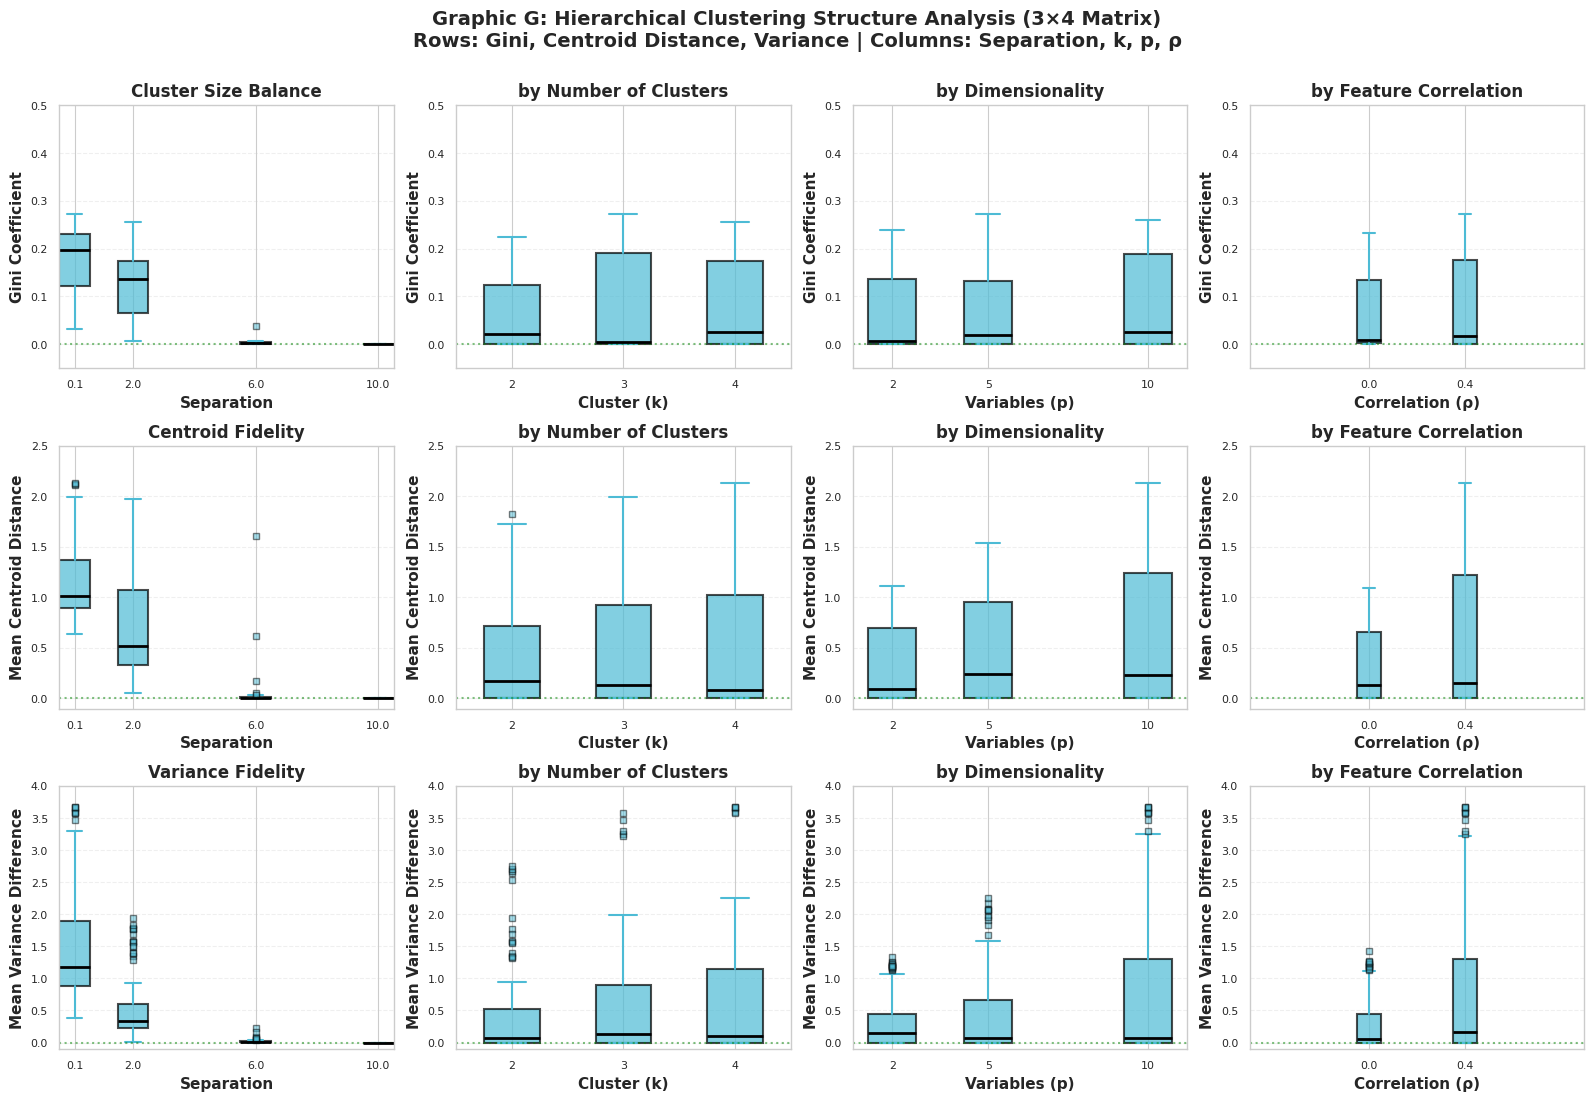

✅ Graphic G saved: graphicG_hierarchical_matrix_3x4.png


In [25]:
# ============================================================================
# GRAPHIC G: Hierarchical Clustering Only - 3×4 Matrix Panel
# Goal: Clean visualization of Hierarchical Clustering performance
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# Create 3×4 subplot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

# Hierarchical color scheme
hc_color = '#4DBBD5'

# Filter for Hierarchical Clustering only
df_gini_hc = df_gini_long[df_gini_long['Algorithm'] == 'Hierarchical']
df_centroid_hc = df_centroid_long[df_centroid_long['Algorithm'] == 'Hierarchical']
df_variance_hc = df_variance_long[df_variance_long['Algorithm'] == 'Hierarchical']

# ============================================================================
# ROW 1: GINI COEFFICIENT
# ============================================================================

# Column 1: By Separation
ax = axes[0, 0]
positions = sorted(df_gini_hc['sep'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['sep'] == pos]['Gini'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Cluster Size Balance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[0, 1]
k_vals = sorted(df_gini_hc['k'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['k'] == k]['Gini'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[0, 2]
p_vals = sorted(df_gini_hc['p'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['p'] == p]['Gini'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[0, 3]
rho_vals = sorted(df_gini_hc['rho'].unique())
data_to_plot = [df_gini_hc[df_gini_hc['rho'] == r]['Gini'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Gini Coefficient', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.05, 0.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 2: CENTROID DISTANCE
# ============================================================================

# Column 1: By Separation
ax = axes[1, 0]
positions = sorted(df_centroid_hc['sep'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['sep'] == pos]['Centroid_Distance'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('Centroid Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[1, 1]
k_vals = sorted(df_centroid_hc['k'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['k'] == k]['Centroid_Distance'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[1, 2]
p_vals = sorted(df_centroid_hc['p'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['p'] == p]['Centroid_Distance'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[1, 3]
rho_vals = sorted(df_centroid_hc['rho'].unique())
data_to_plot = [df_centroid_hc[df_centroid_hc['rho'] == r]['Centroid_Distance'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Centroid Distance', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 2.5)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# ============================================================================
# ROW 3: VARIANCE DIFFERENCE
# ============================================================================

# Column 1: By Separation
ax = axes[2, 0]
positions = sorted(df_variance_hc['sep'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['sep'] == pos]['Variance_Difference'].values for pos in positions]
bp = ax.boxplot(data_to_plot, positions=positions, widths=1.0, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Separation', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('Variance Fidelity', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 2: By Cluster
ax = axes[2, 1]
k_vals = sorted(df_variance_hc['k'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['k'] == k]['Variance_Difference'].values for k in k_vals]
bp = ax.boxplot(data_to_plot, positions=k_vals, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Cluster (k)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Number of Clusters', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(k_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 3: By Variables
ax = axes[2, 2]
p_vals = sorted(df_variance_hc['p'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['p'] == p]['Variance_Difference'].values for p in p_vals]
bp = ax.boxplot(data_to_plot, positions=p_vals, widths=1.5, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Variables (p)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Dimensionality', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(p_vals)
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

# Column 4: By Correlation
ax = axes[2, 3]
rho_vals = sorted(df_variance_hc['rho'].unique())
data_to_plot = [df_variance_hc[df_variance_hc['rho'] == r]['Variance_Difference'].values for r in rho_vals]
bp = ax.boxplot(data_to_plot, positions=rho_vals, widths=0.1, patch_artist=True,
                boxprops=dict(facecolor=hc_color, alpha=0.7, linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=hc_color, linewidth=1.5),
                capprops=dict(color=hc_color, linewidth=1.5),
                flierprops=dict(marker='s', markerfacecolor=hc_color, markersize=4, alpha=0.5))
ax.set_xlabel('Correlation (ρ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Variance Difference', fontsize=11, fontweight='bold')
ax.set_title('by Feature Correlation', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 4.0)
ax.axhline(y=0, color='green', linestyle=':', linewidth=1.5, alpha=0.5)

fig.suptitle('Graphic G: Hierarchical Clustering Structure Analysis (3×4 Matrix)\n'
             'Rows: Gini, Centroid Distance, Variance | Columns: Separation, k, p, ρ',
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('graphicG_hierarchical_matrix_3x4.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Graphic G saved: graphicG_hierarchical_matrix_3x4.png")